In [2]:
#List of mice to include in the analysis

RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\013125\G6CK14BLN',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\021225']
                   

SalineRecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\052124\J691RT',
                   r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']


figpath = r'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 6 - SFTF tuning'


In [13]:
#Importing Important Stuff
import scipy.interpolate as interpolate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat 
import math 
from pylab import *
import os
import fmEphys as fme
import sys
import scipy
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc
import sklearn.cluster
import fmEphys as fme
import pickle
from scipy import stats
from tqdm import tqdm

In [4]:
def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x


def calc_PSTH_modind(psth, trange='fm'):
    """ PSTH modulation index.
    
    There are three possible ranges to use for the
    baseline and activity periods:
    For eye/head movements, the baseline value is calculated
    from -1000 ms until -200 ms before the movement onset. The
    active period


    Parameters
    ----------
    psth : array
        PSTH to calculate modulation index for. Should have
        the shape (time,) and be either of the length 2001
        or 3001 (i.e., either -1000 to 1000 (plus the 0
        timepoint) or -1500 to 1500 (plus the 0 timepoint)).
    trange : str
        Time range to use for the baseline and active periods.
        Options are
            'fm'
        For freely moving eye/head movements. Baseline
        is -1000 to -200 ms before movement onset, and active
        is 0 to 1000 ms after movement onset.
            'fl'
        For fast flashed stimuli. Baseline is 0 ms before
        stimulus onset (meaning it is only that single timepoint),
        and active is 0 to 1000 ms after onset.
            'gt'
        For gratings. These PSTHs were calculated from -1500 to
        1500 ms, so the baseline is centered around the stimulus
        onset at the index 1501 instead of at the index 1001. The
        baseline is -400 ms to -100 ms before stimulus onset, and
        the active period is 0 ms until 1500 ms after stimulus.

        'fl' (for fast flashed stimuli which do not have time
        to return to baseline after each stimulus)

    """

    if type(psth) != float:
        psth = psth.astype(float)
    elif type(psth) == float:
        return np.nan

    # FOr freely moving eye/head movements
    if trange=='fm':

        # Use the response window with the baseline subtracted
        # baseline = t[-1000 ms -> -200 ms]
        use = psth - np.mean(psth[0:800].copy())

        # Calculate modulation
        # maximum response of |response window|
        mod = np.max(np.abs(use[1000:1250]))

    # For flashed head-fixed stimuli
    elif trange=='sn':

        # Subtract the reponse at t=0
        bsln = psth[1000]
        use = psth.copy() - bsln
        
        mod = np.max(np.abs(use[1000:1250]))

    # For drifting gratings
    elif trange=='gt':

        bsln = np.mean(psth[1100:1400].copy())
        use = psth.copy() - bsln

        mod = np.max(np.abs(use[1500:2400]))

    return mod



def calc_std_modidx(psth,thresh,trange = 'fm'):
    if trange == 'fm':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[100:800])

        std_thresh = np.nanstd(psth[100:800]*thresh)
    
        if np.nanmax((np.abs(psth[975:1500])-std_thresh)) > 0:
            mod = 1
        else:
            mod = 0 

    elif trange == 'gt':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[1100:1400])

        std_thresh = np.nanstd(psth[1100:1400]*thresh)
    
        if np.nanmax((np.abs(psth[1500:2400])-std_thresh)) > 0:
            mod = 1
        else:
            mod = 0 
    
    return mod

def calc_fr_modidx(psth,thresh,trange = 'fm'):
    if trange == 'fm':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[100:800])

        if np.nanmax(np.abs(psth[975:1500])) > thresh:
            mod = 1
        else:
            mod = 0

    if trange == 'gt':
        psth = psth.astype(float)
        psth = psth - np.nanmean(psth[1100:1400])

        if np.nanmax(np.abs(psth[1500:2400])) > thresh:
            mod = 1
        else:
            mod = 0

    return mod

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=2)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.1)
    #plt.legend()

def calc_kde_PSTH(spikeT, eventT, bandwidth=10, resample_size=1,
                      edgedrop=15, win=1000):
        """Calculate PSTH for a single unit.

        The Peri-Stimulus Time Histogram (PSTH) will be calculated using Kernel
        Density Estimation by sliding a gaussian along the spike times centered
        on the event time.

        Because the gaussian filter will create artifacts at the edges (i.e. the
        start and end of the time window), it's best to add extra time to the start
        and end and then drop that time from the PSTH, leaving the final PSTH with no
        artifacts at the start and end. The time (in msec) set with `edgedrop` pads
        the start and end with some time which is dropped from the final PSTH before
        the PSTH is returned.

        Parameters
        ----------
        spikeT : np.array
            Array of spike times in seconds and with the type float. Should be 1D and be
            the spike times for a single ephys unit.
        eventT : np.array
            Array of event times (e.g. presentation of stimulus or the time of a saccade)
            in seconds and with the type float.
        bandwidth : int
            Bandwidth of KDE filter in units of milliseconds.
        resample_size : int
            Size of binning when resampling spike rate, in units of milliseconds.
        edgedrop : int
            Time to pad at the start and end, and then dropped, to eliminate edge artifacts.
        win : int
            Window in time to use in positive and negative directions. For win=1000, the
            PSTH will start -1000 ms before the event and end +1000 ms after the event.

        Returns
        -------
        psth : np.array
            Peri-Stimulus Time Histogram

        """

        # Unit conversions
        bandwidth = bandwidth / 1000
        resample_size = resample_size / 1000
        win = win / 1000
        edgedrop = edgedrop / 1000
        edgedrop_ind = int(edgedrop / resample_size)

        bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

        # Timestamps of spikes (`sps`) relative to `eventT`
        sps = []
        for i, t in enumerate(eventT):
            sp = spikeT-t
            # Only keep spikes in this window
            sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))] 
            sps.extend(sp)
        sps = np.array(sps)

        if len(sps) < 10:
            n_bins = int((win * 1000 * 2) + 1)
            return np.zeros(n_bins)*np.nan

        kernel = sklearn.neighbors.KernelDensity(kernel='gaussian',
                                                 bandwidth=bandwidth).fit(sps[:, np.newaxis])
        density = kernel.score_samples(bins[:, np.newaxis])

        # Multiply by the # spikes to get spike count per point. Divide
        # by # events for rate/event.
        psth = np.exp(density) * (np.size(sps ) / np.size(eventT))

        # Drop padding at start & end to eliminate edge effects.
        psth = psth[edgedrop_ind:-edgedrop_ind]

        return psth

In [5]:
#making master file of all recordings - DOI
Grating_Files = [[] for _ in range(len(RecordingsToUse))]
Grating_Files_Raw = [[] for _ in range(len(RecordingsToUse))]
Single_Unit_Files = []

GratingData_DOI = pd.DataFrame()
GratingData_Raw_PreDOI = pd.DataFrame()
GratingData_Raw_PostDOI = pd.DataFrame()

for ii in list(range(0,len(RecordingsToUse))):
   
    RecordingPath = RecordingsToUse[ii]
    
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
           Single_Unit_Files.append(RecordingPath +'/' + Items)
           
    Single_Units = np.load(Single_Unit_Files[ii])
    print(len(Single_Units))

    #Finding drifting grating ephys .h5 files
    
    for folders in os.listdir(RecordingPath):
        if folders.endswith("grating_data.h5"):
            Grating_Files[ii].append(RecordingPath +'/' + folders)

        if folders.endswith("gratings"):
            for gratingsubfolder in os.listdir(RecordingPath +'/' + folders):
                if gratingsubfolder.endswith("ephys_props.h5"):
                    Grating_Files_Raw[ii].append(RecordingPath +'/' + folders + '/' + gratingsubfolder)

    GratingData_temp = pd.read_hdf(Grating_Files[ii][0])
    GratingData_DOI = pd.concat([GratingData_DOI, GratingData_temp])

    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][0])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PreDOI = pd.concat([GratingData_Raw_PreDOI, GratingDataRaw_temp])
    
    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][1])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PostDOI = pd.concat([GratingData_Raw_PostDOI, GratingDataRaw_temp])

#Removing these cells because they have been previously removed in the GazeShift dataset below
DOI_ToRemove = [3,4,5,17,21,23,31,32,33,46,47,49,53,54,58,66,78,91,128,135,137,138,139,140,141,150,151,52,153,154,155,156,157,158,172,173,180,195,216,219,221,350,431,437,473,485,502,509,518,528,529,530,531,533,542,543,544,546,549,554,584,585,588,590,595,597,599,607,609,612,613,614,615,616]  #These clusters dont have biologically realistic waveforms

GratingData_DOI.reset_index(drop=True,inplace=True)
#GratingData_DOI = GratingData_DOI.drop(DOI_ToRemove)

GratingData_Raw_PreDOI.reset_index(drop=True,inplace=True)
#GratingData_Raw_PreDOI = GratingData_Raw_PreDOI.drop(DOI_ToRemove)

GratingData_Raw_PostDOI.reset_index(drop=True,inplace=True)
#GratingData_Raw_PostDOI = GratingData_Raw_PostDOI.drop(DOI_ToRemove)

GazeData_DOI = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\DGMice_GazeShifts_DOI.h5")

print(np.shape(GratingData_DOI))
print(np.shape(GratingData_Raw_PreDOI))
print(np.shape(GratingData_Raw_PostDOI))
print(np.shape(GazeData_DOI))

66
12
106
88
139
90
87
23
7
(618, 23)
(618, 58)
(618, 58)
(618, 21)


In [6]:
#making master file of all recordings - Saline
Grating_Files = [[] for _ in range(len(RecordingsToUse))]
Grating_Files_Raw = [[] for _ in range(len(RecordingsToUse))]
Single_Unit_Files = []
GratingData_Saline = pd.DataFrame()
GratingData_Raw_PreSaline = pd.DataFrame()
GratingData_Raw_PostSaline = pd.DataFrame()

for ii in list(range(0,len(SalineRecordingsToUse))):
   
    RecordingPath = SalineRecordingsToUse[ii]
    
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
           Single_Unit_Files.append(RecordingPath +'/' + Items)
           
    Single_Units = np.load(Single_Unit_Files[ii])
    print(len(Single_Units))

    #Finding drifting grating ephys .h5 files
    
    for folders in os.listdir(RecordingPath):
        if folders.endswith("grating_data.h5"):
            Grating_Files[ii].append(RecordingPath +'/' + folders)

        if folders.endswith("gratings"):
            for gratingsubfolder in os.listdir(RecordingPath +'/' + folders):
                if gratingsubfolder.endswith("ephys_props.h5"):
                    Grating_Files_Raw[ii].append(RecordingPath +'/' + folders + '/' + gratingsubfolder)
                   
    GratingData_temp = pd.read_hdf(Grating_Files[ii][0])
    GratingData_Saline = pd.concat([GratingData_Saline, GratingData_temp])

    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][0])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PreSaline = pd.concat([GratingData_Raw_PreSaline, GratingDataRaw_temp])
    
    GratingDataRaw_temp = pd.read_hdf(Grating_Files_Raw[ii][1])
    GratingDataRaw_temp = GratingDataRaw_temp.loc[Single_Units]
    GratingData_Raw_PostSaline = pd.concat([GratingData_Raw_PostSaline, GratingDataRaw_temp])



#Removing these cells because they have been previously removed in the GazeShift dataset below
#Saline_ToRemove = [40,47,68,71,134,136,138,229,234,246,262]  #These clusters dont have biologically realistic waveforms

GratingData_Saline.reset_index(drop=True,inplace=True)
#GratingData_Saline = GratingData_Saline.drop(Saline_ToRemove)

GratingData_Raw_PreSaline.reset_index(drop=True,inplace=True)
#GratingData_Raw_PreSaline = GratingData_Raw_PreSaline.drop(Saline_ToRemove)

GratingData_Raw_PostSaline.reset_index(drop=True,inplace=True)
#GratingData_Raw_PostSaline = GratingData_Raw_PostSaline.drop(Saline_ToRemove)

GazeData_Saline = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\AllMice_GazeShift_Saline.h5")
#GazeData_Saline.reset_index(drop=True,inplace=True)
#GazeData_Saline = GazeData_Saline.drop(Saline_ToRemove)

print(np.shape(GratingData_Saline))
print(np.shape(GratingData_Raw_PreSaline))
print(np.shape(GratingData_Raw_PostSaline))
print(np.shape(GazeData_Saline))

19
50
145
50
(264, 23)
(264, 58)
(264, 58)
(264, 21)


Finding Responsive Cells

def find_substring_in_array(string_array, substring):
    indices = []
    for index, string in enumerate(string_array):
        if substring in string:
            indices.append(index)
    return indices

In [446]:
np.unique(GazeData_DOI['Mouse'])

array(['012324_G6CK11BTT', '013125_G6CK14BLN', '022024_G6CK10DTT',
       '072624_J708LT', '080224_J705RT', '081024_J720LT', '110723_J683LT',
       '122024_J728LT', '2025_021225'], dtype=object)

In [7]:
#CONTAMINATION INDEX THRESHOLDING

DOI_NotContaminted = np.where(GazeData_DOI.loc[:,'Contamination_Idx']<=30)
Saline_NotContaminted = np.where(GazeData_Saline.loc[:,'Contamination_Idx']<=30)

print(len(np.squeeze(DOI_NotContaminted)))
print(len(np.squeeze(Saline_NotContaminted)))
print(len(np.squeeze(DOI_NotContaminted))/len(GazeData_DOI))
print(len(np.squeeze(Saline_NotContaminted))/len(GazeData_Saline))

GazeData_DOI = GazeData_DOI.iloc[DOI_NotContaminted]
GazeData_Saline = GazeData_Saline.iloc[Saline_NotContaminted]

GratingData_DOI = GratingData_DOI.iloc[DOI_NotContaminted]
GratingData_Saline = GratingData_Saline.iloc[Saline_NotContaminted]

374
148
0.6051779935275081
0.5606060606060606


In [8]:
#Finding Responsive cells - DOI
Av_PSTH_PreDOI = np.stack(GratingData_DOI['Av_PSTH_Pre']) 
PreDOI_Baselines = np.nanmean(Av_PSTH_PreDOI[:,1100:1400].copy(),axis=1)
Av_PSTH_PreDOI_Baselined = Av_PSTH_PreDOI - PreDOI_Baselines[:,None]
Av_PSTH_PreDOI_Norm = Av_PSTH_PreDOI_Baselined/ np.nanmax(np.abs(Av_PSTH_PreDOI[:,1500:2500]),axis=1)[:,None]

NormFR_Thresh_Pre = np.nanmax(Av_PSTH_PreDOI_Norm[:,1525:2400],axis=1)

FR_Thresh_Pre = np.zeros(len(GratingData_DOI))
STD_Thresh_Pre = np.zeros(len(GratingData_DOI))

for ii in range(0,len(GratingData_DOI)):
    FR_Thresh_Pre[ii] = calc_fr_modidx(Av_PSTH_PreDOI_Baselined[ii],1,'gt')
    STD_Thresh_Pre[ii] = calc_std_modidx(Av_PSTH_PreDOI_Baselined[ii],3.5,'gt')

NormFR_Thresh_Pre[NormFR_Thresh_Pre<.5] = 0
NormFR_Thresh_Pre[NormFR_Thresh_Pre>.5] = 1

#PreDOI_Grating_Responsive = (FR_Thresh_Pre + STD_Thresh_Pre + NormFR_Thresh_Pre) - 2
PreDOI_Grating_Responsive = (FR_Thresh_Pre  + NormFR_Thresh_Pre) - 1
PreDOI_Grating_Responsive[PreDOI_Grating_Responsive<1] = 0
PreDOI_Grating_Responsive[np.isnan(PreDOI_Grating_Responsive)] = 0

#####

Av_PSTH_PostDOI = np.stack(GratingData_DOI['Av_PSTH_Post']) 
PostDOI_Baselines = np.nanmean(Av_PSTH_PostDOI[:,1100:1400].copy(),axis=1)
Av_PSTH_PostDOI_Baselined = Av_PSTH_PostDOI - PostDOI_Baselines[:,None]
Av_PSTH_PostDOI_Norm = Av_PSTH_PostDOI_Baselined/ np.nanmax(np.abs(Av_PSTH_PostDOI[:,1500:2500]),axis=1)[:,None]

NormFR_Thresh_Post = np.nanmax(Av_PSTH_PostDOI_Norm[:,1525:2400],axis=1)

FR_Thresh_Post = np.zeros(len(GratingData_DOI))
STD_Thresh_Post = np.zeros(len(GratingData_DOI))

for ii in range(0,len(GratingData_DOI)):
    FR_Thresh_Post[ii] = calc_fr_modidx(Av_PSTH_PostDOI_Baselined[ii],1,'gt')
    STD_Thresh_Post[ii] = calc_std_modidx(Av_PSTH_PostDOI_Baselined[ii],3.5,'gt')

NormFR_Thresh_Post[NormFR_Thresh_Post<.5] = 0
NormFR_Thresh_Post[NormFR_Thresh_Post>.5] = 1

#PostDOI_Grating_Responsive = (FR_Thresh_Post + STD_Thresh_Post + NormFR_Thresh_Post) - 2 
PostDOI_Grating_Responsive = (FR_Thresh_Post  + NormFR_Thresh_Post) - 1  
PostDOI_Grating_Responsive[PostDOI_Grating_Responsive<1] = 0
PostDOI_Grating_Responsive[np.isnan(PostDOI_Grating_Responsive)] = 0

DOI_Grating_ResponsivetoBoth = (PreDOI_Grating_Responsive + PostDOI_Grating_Responsive) - 1
DOI_Grating_ResponsivetoBoth[DOI_Grating_ResponsivetoBoth<1] = 0

########################################################

#Finding Responsive cells - Saline
Av_PSTH_PreSaline = np.stack(GratingData_Saline['Av_PSTH_Pre']) 
PreSaline_Baselines = np.nanmean(Av_PSTH_PreSaline[:,1100:1400].copy(),axis=1)
Av_PSTH_PreSaline_Baselined = Av_PSTH_PreSaline - PreSaline_Baselines[:,None]
Av_PSTH_PreSaline_Norm = Av_PSTH_PreSaline_Baselined/ np.nanmax(np.abs(Av_PSTH_PreSaline[:,1500:2500]),axis=1)[:,None]

NormFR_Thresh_Pre = np.nanmax(Av_PSTH_PreSaline_Norm[:,1525:2400],axis=1)

FR_Thresh_Pre_Saline = np.zeros(len(GratingData_Saline))
STD_Thresh_Pre_Saline = np.zeros(len(GratingData_Saline))

for ii in range(0,len(GratingData_Saline)):
    FR_Thresh_Pre_Saline[ii] = calc_fr_modidx(Av_PSTH_PreSaline_Baselined[ii],1,'gt')
    STD_Thresh_Pre_Saline[ii] = calc_std_modidx(Av_PSTH_PreSaline_Baselined[ii],3.5,'gt')

NormFR_Thresh_Pre[NormFR_Thresh_Pre<.5] = 0
NormFR_Thresh_Pre[NormFR_Thresh_Pre>.5] = 1

#PreSaline_Grating_Responsive = (FR_Thresh_Pre_Saline + STD_Thresh_Pre_Saline + NormFR_Thresh_Pre) - 2 
PreSaline_Grating_Responsive = (FR_Thresh_Pre_Saline + NormFR_Thresh_Pre) - 1
PreSaline_Grating_Responsive[PreSaline_Grating_Responsive<1] = 0
PreSaline_Grating_Responsive[np.isnan(PreSaline_Grating_Responsive)] = 0

#####

Av_PSTH_PostSaline = np.stack(GratingData_Saline['Av_PSTH_Post']) 
PostSaline_Baselines = np.nanmean(Av_PSTH_PostSaline[:,1100:1400].copy(),axis=1)
Av_PSTH_PostSaline_Baselined = Av_PSTH_PostSaline - PostSaline_Baselines[:,None]
Av_PSTH_PostSaline_Norm = Av_PSTH_PostSaline_Baselined/ np.nanmax(np.abs(Av_PSTH_PostSaline[:,1500:2500]),axis=1)[:,None]

NormFR_Thresh_Post = np.nanmax(Av_PSTH_PostSaline_Norm[:,1525:2400],axis=1)

FR_Thresh_Post_Saline = np.zeros(len(GratingData_Saline))
STD_Thresh_Post_Saline = np.zeros(len(GratingData_Saline))

for ii in range(0,len(GratingData_Saline)):
    FR_Thresh_Post_Saline[ii] = calc_fr_modidx(Av_PSTH_PostSaline_Baselined[ii],1,'gt')
    STD_Thresh_Post_Saline[ii] = calc_std_modidx(Av_PSTH_PostSaline_Baselined[ii],3.5,'gt')

NormFR_Thresh_Post[NormFR_Thresh_Post<.5] = 0
NormFR_Thresh_Post[NormFR_Thresh_Post>.5] = 1

#PostSaline_Grating_Responsive = (FR_Thresh_Post_Saline + STD_Thresh_Post_Saline + NormFR_Thresh_Post) - 2 
PostSaline_Grating_Responsive = (FR_Thresh_Post_Saline + NormFR_Thresh_Post) - 1 
PostSaline_Grating_Responsive[PostSaline_Grating_Responsive<1] = 0
PostSaline_Grating_Responsive[np.isnan(PostSaline_Grating_Responsive)] = 0

Saline_Grating_ResponsivetoBoth = (PreSaline_Grating_Responsive + PostSaline_Grating_Responsive) - 1
Saline_Grating_ResponsivetoBoth[Saline_Grating_ResponsivetoBoth<1] = 0

Normalizing Average Grating Response to Max Value across Pre and Post DOI Conditions

In [9]:
print(np.sum(PreDOI_Grating_Responsive))
print(np.sum(PostDOI_Grating_Responsive))
print(np.sum(DOI_Grating_ResponsivetoBoth))
print()
print(np.sum(PreSaline_Grating_Responsive))
print(np.sum(PostSaline_Grating_Responsive))
print(np.sum(Saline_Grating_ResponsivetoBoth))
print()
print(np.sum(PreDOI_Grating_Responsive)/len(DOI_Grating_ResponsivetoBoth))
print(np.sum(PostDOI_Grating_Responsive)/len(DOI_Grating_ResponsivetoBoth))
print(np.sum(DOI_Grating_ResponsivetoBoth)/len(DOI_Grating_ResponsivetoBoth))
print()
print(np.sum(PreSaline_Grating_Responsive)/len(Saline_Grating_ResponsivetoBoth))
print(np.sum(PostSaline_Grating_Responsive)/len(Saline_Grating_ResponsivetoBoth))
print(np.sum(Saline_Grating_ResponsivetoBoth)/len(Saline_Grating_ResponsivetoBoth))


190.0
173.0
154.0

86.0
87.0
80.0

0.5080213903743316
0.4625668449197861
0.4117647058823529

0.581081081081081
0.5878378378378378
0.5405405405405406


In [10]:
#####DOI
#Max value for normalizing
Av_PSTH_PreDOI = np.stack(GratingData_DOI['Av_PSTH_Pre']) 
Av_PSTH_PreDOI = Av_PSTH_PreDOI[PreDOI_Grating_Responsive.astype(bool)]
Av_PSTH_PostDOI = np.stack(GratingData_DOI['Av_PSTH_Post']) 
Av_PSTH_PostDOI = Av_PSTH_PostDOI[PreDOI_Grating_Responsive.astype(bool)]

MxDOI = [np.nanmax(Av_PSTH_PreDOI,axis =1),np.nanmax(Av_PSTH_PostDOI,axis =1)]
MxDOI = np.nanmax(MxDOI,axis=0)
#baselines to be subtracted off
PreDOI_Baseline = np.nanmean(Av_PSTH_PreDOI[:,1100:1400],axis =1)
PostDOI_Baseline = np.nanmean(Av_PSTH_PostDOI[:,1100:1400],axis =1)
#Normalizing 
Av_PSTH_PreDOI = Av_PSTH_PreDOI - PreDOI_Baseline [:,None]
Av_PSTH_PostDOI = Av_PSTH_PostDOI - PostDOI_Baseline[:,None]
Av_PSTH_Norm_PreDOI = Av_PSTH_PreDOI/MxDOI[:,None]
Av_PSTH_Norm_PostDOI = Av_PSTH_PostDOI/MxDOI[:,None]


#####Saline
#Max value for normalizing
Av_PSTH_PreSaline = np.stack(GratingData_Saline['Av_PSTH_Pre']) 
Av_PSTH_PreSaline = Av_PSTH_PreSaline[PreSaline_Grating_Responsive.astype(bool)]
Av_PSTH_PostSaline = np.stack(GratingData_Saline['Av_PSTH_Post']) 
Av_PSTH_PostSaline = Av_PSTH_PostSaline[PreSaline_Grating_Responsive.astype(bool)]

MxSaline = [np.nanmax(Av_PSTH_PreSaline,axis =1),np.nanmax(Av_PSTH_PostSaline,axis =1)]
MxSaline = np.nanmax(MxSaline,axis=0)
#baselines to be subtracted off
PreSaline_Baseline = np.nanmean(Av_PSTH_PreSaline[:,1000:1500],axis =1)
PostSaline_Baseline = np.nanmean(Av_PSTH_PostSaline[:,1000:1500],axis =1)
#Normalizing 
Av_PSTH_PreSaline = Av_PSTH_PreSaline - PreSaline_Baseline [:,None]
Av_PSTH_PostSaline = Av_PSTH_PostSaline - PostSaline_Baseline[:,None]
Av_PSTH_Norm_PreSaline = Av_PSTH_PreSaline/MxSaline[:,None]
Av_PSTH_Norm_PostSaline = Av_PSTH_PostSaline/MxSaline[:,None]

Plotting Mean (+- SEM) Average Grating Response before and after DOI

In [385]:
All_Mdx_DOI = (np.nanmax(Av_PSTH_Norm_PostDOI[:,1400:3000],axis=0)-np.nanmax(Av_PSTH_Norm_PreDOI[:,1400:3000],axis=0))/(np.nanmax(Av_PSTH_Norm_PostDOI[:,1400:3000],axis=0)+np.nanmax(Av_PSTH_Norm_PreDOI[:,1400:3000],axis=0))
All_Mdx_Saline = (np.nanmax(Av_PSTH_Norm_PostSaline[:,1400:3000],axis=0)-np.nanmax(Av_PSTH_Norm_PreSaline[:,1400:3000],axis=0))/(np.nanmax(Av_PSTH_Norm_PostSaline[:,1400:3000],axis=0)+np.nanmax(Av_PSTH_Norm_PreSaline[:,1400:3000],axis=0))

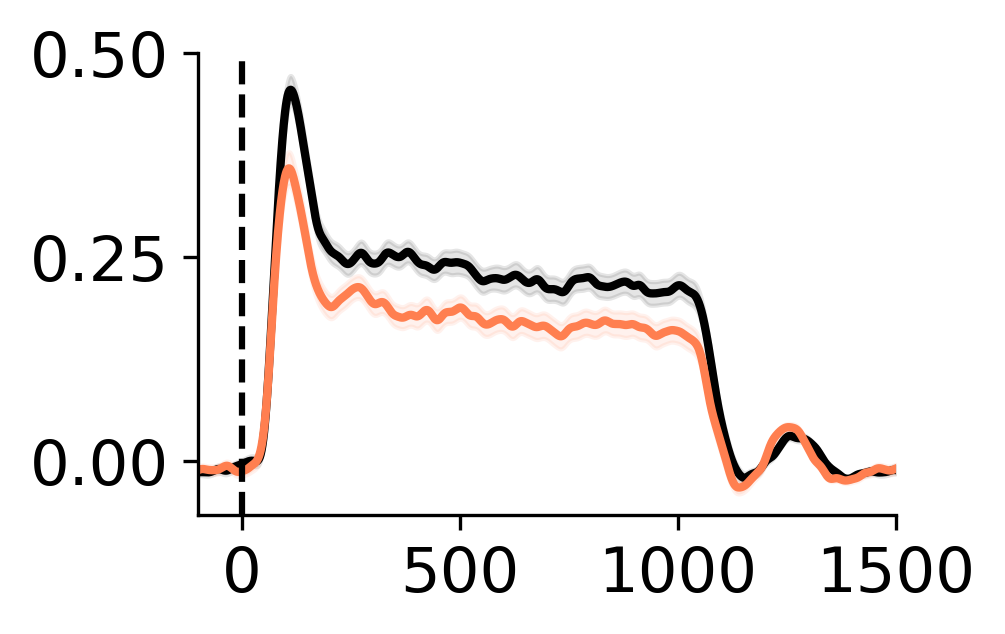

In [11]:


#Mean average grating response before and after DOI
Av_PSTH_PreDOI_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PreDOI[:,1400:3000]),axis=0)
Av_PSTH_PostDOI_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PostDOI[:,1400:3000]),axis=0)

#STE average Grating Response before and after DOI
Av_PSTH_PreDOI_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PreDOI[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PreDOI))
Av_PSTH_PostDOI_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PostDOI[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PostDOI))

# Plotting mean and standard deviation for each group before DOI
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreDOI_Mean, Av_PSTH_PostDOI_Mean],
                                                [Av_PSTH_PreDOI_STE, Av_PSTH_PostDOI_STE],
                                                ['black','coral'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'DOI_AverageNormalizedGratingResponse.eps'),dpi=300)

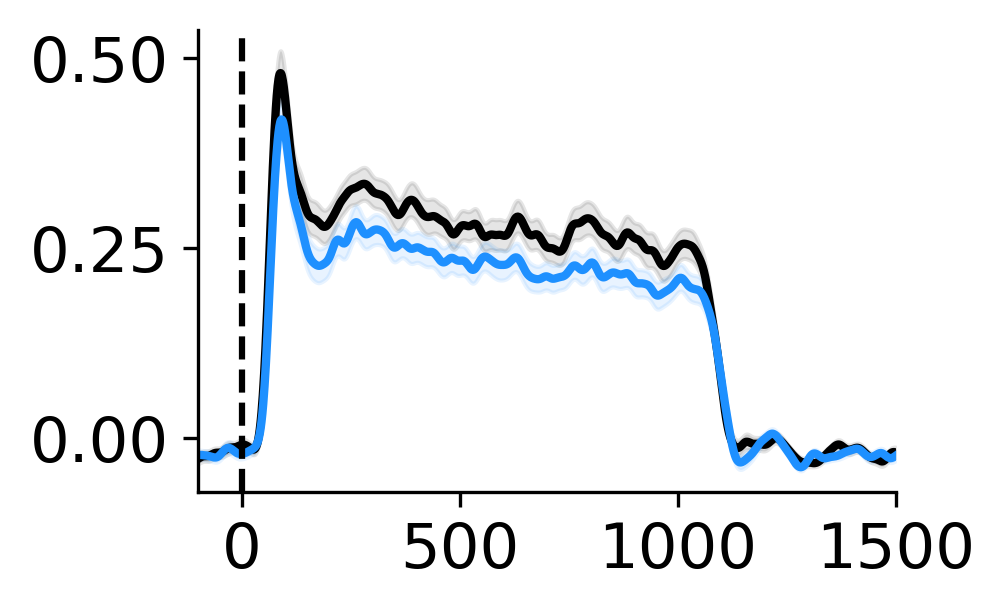

In [12]:


#Mean average grating response before and after DOI
Av_PSTH_Pre_Saline_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PreSaline[:,1400:3000]),axis=0)
Av_PSTH_Post_Saline_Mean = np.nanmean(np.squeeze(Av_PSTH_Norm_PostSaline[:,1400:3000]),axis=0)

#STE average Grating Response before and after DOI
Av_PSTH_Pre_Saline_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PreSaline[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PreSaline))
Av_PSTH_Post_Saline_STE = np.nanstd(np.squeeze(Av_PSTH_Norm_PostSaline[:,1400:3000]),axis=0)/sqrt(len(Av_PSTH_Norm_PostSaline))

# Plotting mean and standard deviation for each group before DOI
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_Pre_Saline_Mean, Av_PSTH_Post_Saline_Mean],
                                                [Av_PSTH_Pre_Saline_STE, Av_PSTH_Post_Saline_STE],
                                                ['black','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'Saline_AverageNormalizedGratingResponse.eps'),dpi=300)

In [16]:
GratingData_DOI.index[Cell]

4

In [436]:
Rasters = GratingData_DOI.loc[4,'SpikeRaster']

In [442]:
np.shape(Rasters[1,1,1,1])

(12,)

100%|██████████| 374/374 [18:35<00:00,  2.98s/it]


<ErrorbarContainer object of 3 artists>

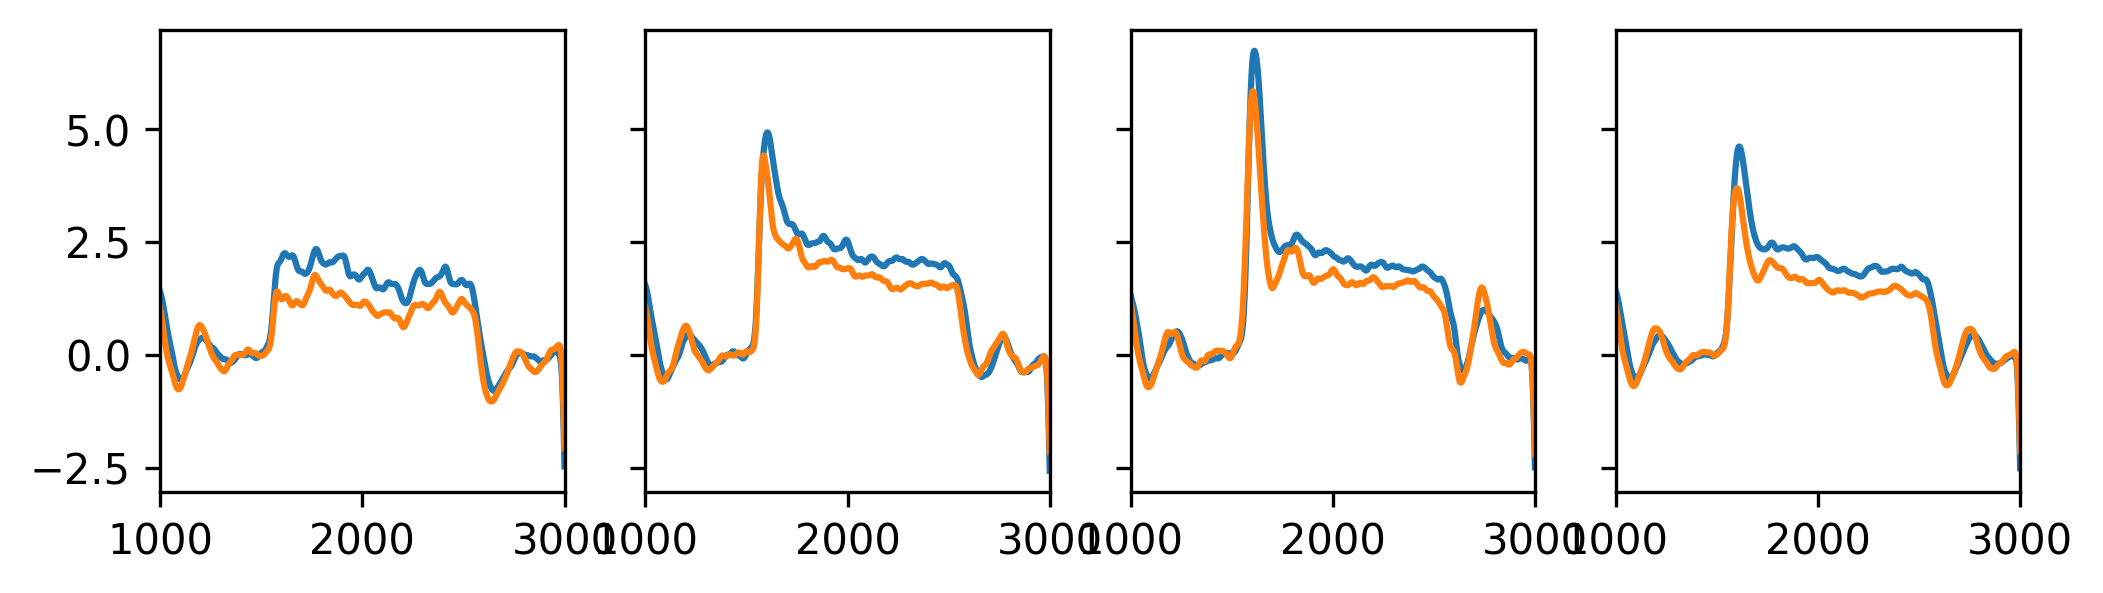

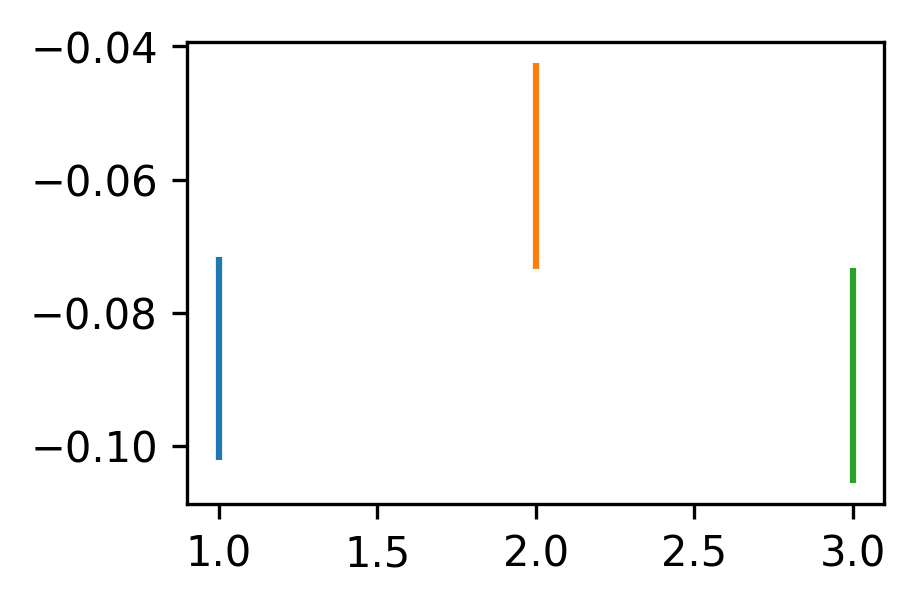

In [17]:
#Calculating Average PSTH to Each SF pre and post DOI

PreDOI_LowSF_PSTH = np.zeros([len(GratingData_DOI),3001])
PreDOI_MedSF_PSTH = np.zeros([len(GratingData_DOI),3001])
PreDOI_HighSF_PSTH = np.zeros([len(GratingData_DOI),3001])

PostDOI_LowSF_PSTH = np.zeros([len(GratingData_DOI),3001])
PostDOI_MedSF_PSTH = np.zeros([len(GratingData_DOI),3001])
PostDOI_HighSF_PSTH = np.zeros([len(GratingData_DOI),3001])

for Cell in tqdm(range(0,len(GratingData_DOI))):
    Idx = GratingData_DOI.index[Cell]
    
    PreDOI_LowSF = []
    PreDOI_MedSF = []
    PreDOI_HighSF = []

    PostDOI_LowSF = []
    PostDOI_MedSF = []
    PostDOI_HighSF = []

    Rasters = GratingData_DOI.loc[Idx,'SpikeRaster']

    for TF in range(0,2):
        for Ori in range(0,8):

            PreDOI_LowSF = np.concatenate([PreDOI_LowSF,Rasters[TF,0,Ori,0]])
            PreDOI_MedSF = np.concatenate([PreDOI_MedSF,Rasters[TF,1,Ori,0]])  
            PreDOI_HighSF = np.concatenate([PreDOI_HighSF,Rasters[TF,2,Ori,0]])

            PostDOI_LowSF = np.concatenate([PostDOI_LowSF,Rasters[TF,0,Ori,1]])
            PostDOI_MedSF = np.concatenate([PostDOI_MedSF,Rasters[TF,1,Ori,1]])  
            PostDOI_HighSF = np.concatenate([PostDOI_HighSF,Rasters[TF,2,Ori,1]])

    ####################################################################################

    PreDOI_LowSF_SpikeT = []
    PreDOI_LowSF_StimT = []
    for ii in range(0,len(PreDOI_LowSF)):
        rep = PreDOI_LowSF[ii] + (ii*5)
        if len(rep) == 1:
            PreDOI_LowSF_SpikeT = np.concatenate([PreDOI_LowSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreDOI_LowSF_SpikeT = np.concatenate([PreDOI_LowSF_SpikeT,np.squeeze(rep)])
    PreDOI_LowSF_StimT = np.arange(0,len(PreDOI_LowSF))*5

    PreDOI_LowSF_PSTH[Cell,:] = calc_kde_PSTH(PreDOI_LowSF_SpikeT, PreDOI_LowSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PreDOI_MedSF_SpikeT = []
    PreDOI_MedSF_StimT = []
    for ii in range(0,len(PreDOI_MedSF)):
        rep = PreDOI_MedSF[ii] + (ii*5)
        if len(rep) == 1:
            PreDOI_MedSF_SpikeT = np.concatenate([PreDOI_MedSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreDOI_MedSF_SpikeT = np.concatenate([PreDOI_MedSF_SpikeT,np.squeeze(rep)])         
    PreDOI_MedSF_StimT = np.arange(0,len(PreDOI_MedSF))*5

    PreDOI_MedSF_PSTH[Cell,:] = calc_kde_PSTH(PreDOI_MedSF_SpikeT, PreDOI_MedSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PreDOI_HighSF_SpikeT = []
    PreDOI_HighSF_StimT = []
    for ii in range(0,len(PreDOI_HighSF)):
        rep = PreDOI_HighSF[ii] + (ii*5)
        if len(rep) == 1:
            PreDOI_HighSF_SpikeT = np.concatenate([PreDOI_HighSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreDOI_HighSF_SpikeT = np.concatenate([PreDOI_HighSF_SpikeT,np.squeeze(rep)])
    PreDOI_HighSF_StimT = np.arange(0,len(PreDOI_HighSF))*5

    PreDOI_HighSF_PSTH[Cell,:] = calc_kde_PSTH(PreDOI_HighSF_SpikeT, PreDOI_HighSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)


    ####################################################################################

    PostDOI_LowSF_SpikeT = []
    PostDOI_LowSF_StimT = []
    for ii in range(0,len(PostDOI_LowSF)):
        rep = PostDOI_LowSF[ii] + (ii*5)
        if len(rep) == 1:
            PostDOI_LowSF_SpikeT = np.concatenate([PostDOI_LowSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostDOI_LowSF_SpikeT = np.concatenate([PostDOI_LowSF_SpikeT,np.squeeze(rep)])
    PostDOI_LowSF_StimT = np.arange(0,len(PostDOI_LowSF))*5

    PostDOI_LowSF_PSTH[Cell,:] = calc_kde_PSTH(PostDOI_LowSF_SpikeT, PostDOI_LowSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PostDOI_MedSF_SpikeT = []
    PostDOI_MedSF_StimT = []
    for ii in range(0,len(PostDOI_MedSF)):
        rep = PostDOI_MedSF[ii] + (ii*5)
        if len(rep) == 1:
            PostDOI_MedSF_SpikeT = np.concatenate([PostDOI_MedSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostDOI_MedSF_SpikeT = np.concatenate([PostDOI_MedSF_SpikeT,np.squeeze(rep)])
    PostDOI_MedSF_StimT = np.arange(0,len(PostDOI_MedSF))*5

    PostDOI_MedSF_PSTH[Cell,:] = calc_kde_PSTH(PostDOI_MedSF_SpikeT, PostDOI_MedSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PostDOI_HighSF_SpikeT = []
    PostDOI_HighSF_StimT = []
    for ii in range(0,len(PostDOI_HighSF)):
        rep = PostDOI_HighSF[ii] + (ii*5)
        if len(rep) == 1:
            PostDOI_HighSF_SpikeT = np.concatenate([PostDOI_HighSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostDOI_HighSF_SpikeT = np.concatenate([PostDOI_HighSF_SpikeT,np.squeeze(rep)])
    PostDOI_HighSF_StimT = np.arange(0,len(PostDOI_HighSF))*5

    PostDOI_HighSF_PSTH[Cell,:] = calc_kde_PSTH(PostDOI_HighSF_SpikeT, PostDOI_HighSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)


###

PreDOI_LowSF_PSTH_Baselined = PreDOI_LowSF_PSTH- np.nanmean(PreDOI_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PreDOI_MedSF_PSTH_Baselined = PreDOI_MedSF_PSTH- np.nanmean(PreDOI_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PreDOI_HighSF_PSTH_Baselined = PreDOI_HighSF_PSTH- np.nanmean(PreDOI_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PostDOI_LowSF_PSTH_Baselined = PostDOI_LowSF_PSTH- np.nanmean(PostDOI_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PostDOI_MedSF_PSTH_Baselined = PostDOI_MedSF_PSTH- np.nanmean(PostDOI_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PostDOI_HighSF_PSTH_Baselined = PostDOI_HighSF_PSTH- np.nanmean(PostDOI_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

Pre_All = np.concatenate([PreDOI_LowSF_PSTH_Baselined,PreDOI_MedSF_PSTH_Baselined,PreDOI_HighSF_PSTH_Baselined])
Post_All = np.concatenate([PostDOI_LowSF_PSTH_Baselined,PostDOI_MedSF_PSTH_Baselined,PostDOI_HighSF_PSTH_Baselined])

fig, axs=plt.subplots(1,4,figsize=(8,2), dpi=300,sharey = True, sharex = True)
axs = axs.ravel()

axs[0].plot(np.nanmean(PreDOI_LowSF_PSTH_Baselined,axis=0))
axs[1].plot(np.nanmean(PreDOI_MedSF_PSTH_Baselined,axis=0))
axs[2].plot(np.nanmean(PreDOI_HighSF_PSTH_Baselined,axis=0))
axs[3].plot(np.nanmean(Pre_All,axis=0))

axs[0].plot(np.nanmean(PostDOI_LowSF_PSTH_Baselined,axis=0))
axs[1].plot(np.nanmean(PostDOI_MedSF_PSTH_Baselined,axis=0))
axs[2].plot(np.nanmean(PostDOI_HighSF_PSTH_Baselined,axis=0))
axs[3].plot(np.nanmean(Post_All,axis=0))

axs[0].set_xlim(1000, 3000)

###

DOI_LowSF_ModIDX = (np.nanmax(PostDOI_LowSF_PSTH_Baselined,axis=1)-np.nanmax(PreDOI_LowSF_PSTH_Baselined,axis=1))/(np.nanmax(PostDOI_LowSF_PSTH_Baselined,axis=1)+np.nanmax(PreDOI_LowSF_PSTH_Baselined,axis=1))
DOI_MedSF_ModIDX = (np.nanmax(PostDOI_MedSF_PSTH_Baselined,axis=1)-np.nanmax(PreDOI_MedSF_PSTH_Baselined,axis=1))/(np.nanmax(PostDOI_MedSF_PSTH_Baselined,axis=1)+np.nanmax(PreDOI_MedSF_PSTH_Baselined,axis=1))
DOI_HighSF_ModIDX = (np.nanmax(PostDOI_HighSF_PSTH_Baselined,axis=1)-np.nanmax(PreDOI_HighSF_PSTH_Baselined,axis=1))/(np.nanmax(PostDOI_HighSF_PSTH_Baselined,axis=1)+np.nanmax(PreDOI_HighSF_PSTH_Baselined,axis=1))

fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
plt.errorbar(1,np.nanmean(DOI_LowSF_ModIDX),yerr=np.nanstd(DOI_LowSF_ModIDX)/np.sqrt(len(DOI_LowSF_ModIDX)))
plt.errorbar(2,np.nanmean(DOI_MedSF_ModIDX),yerr=np.nanstd(DOI_MedSF_ModIDX)/np.sqrt(len(DOI_MedSF_ModIDX)))
plt.errorbar(3,np.nanmean(DOI_HighSF_ModIDX),yerr=np.nanstd(DOI_HighSF_ModIDX)/np.sqrt(len(DOI_HighSF_ModIDX)))

100%|██████████| 148/148 [11:32<00:00,  4.68s/it]


<ErrorbarContainer object of 3 artists>

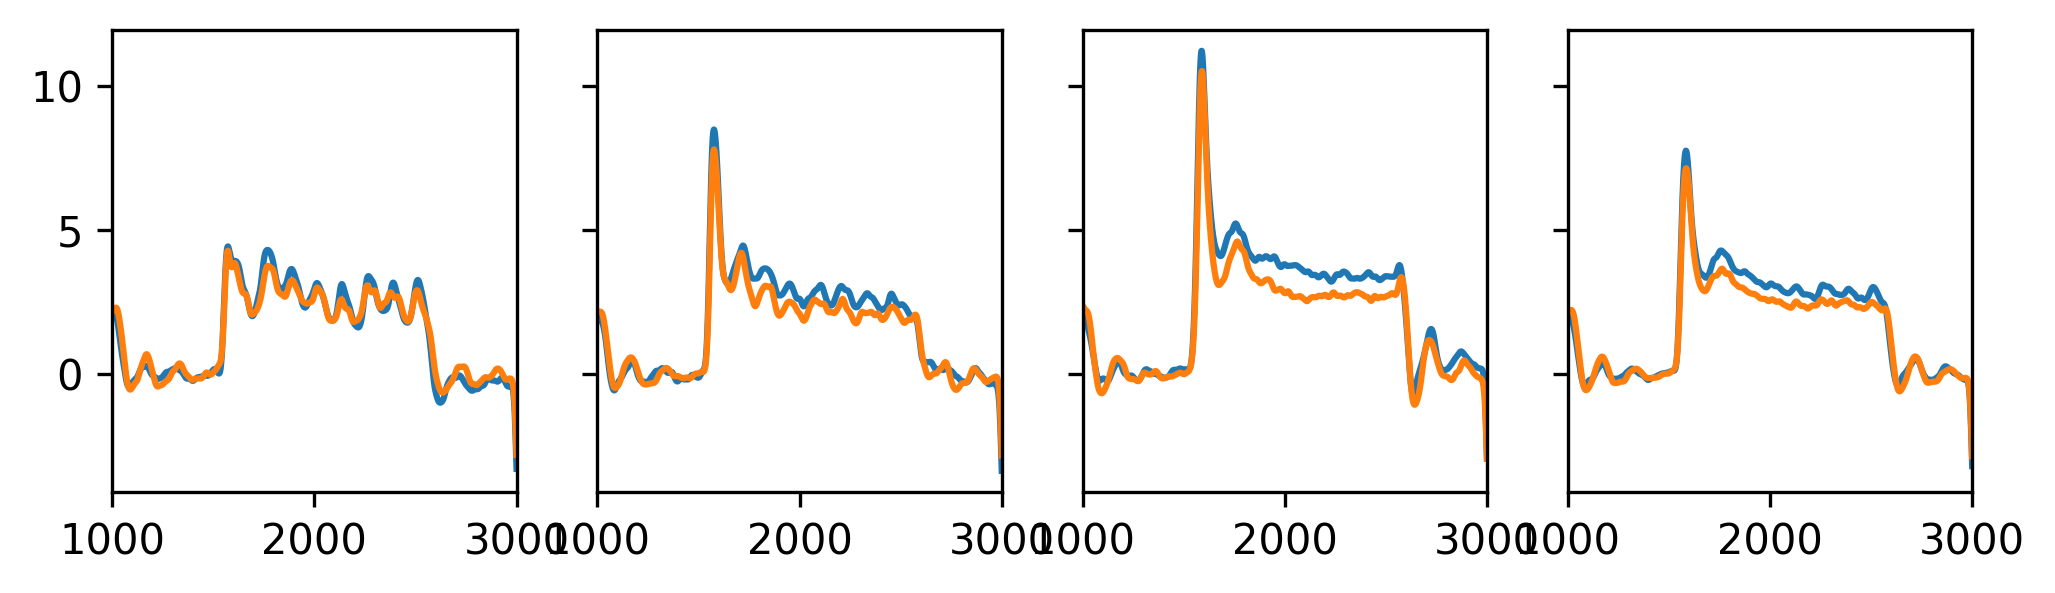

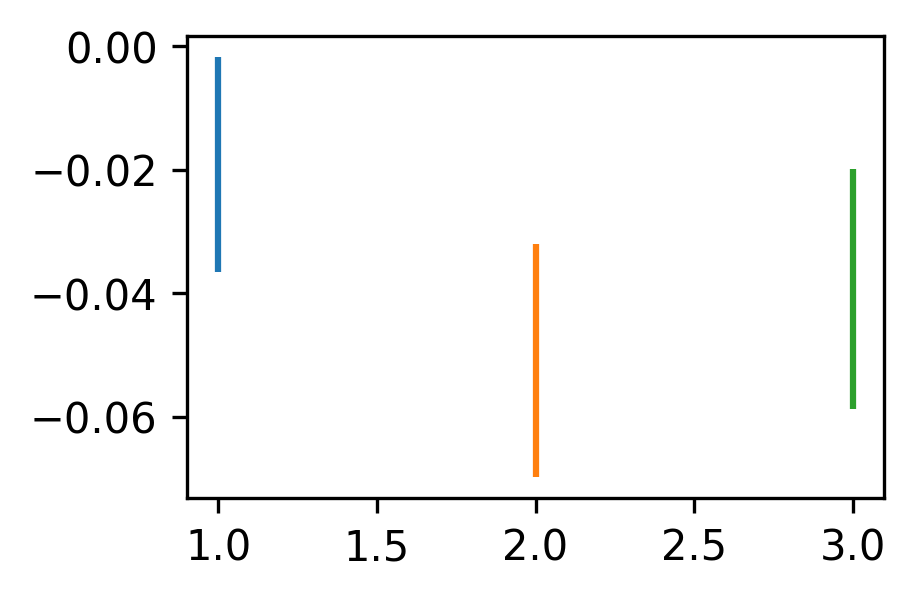

In [19]:
#Calculating Average PSTH to Each SF pre and post Saline

PreSaline_LowSF_PSTH = np.zeros([len(GratingData_Saline),3001])
PreSaline_MedSF_PSTH = np.zeros([len(GratingData_Saline),3001])
PreSaline_HighSF_PSTH = np.zeros([len(GratingData_Saline),3001])

PostSaline_LowSF_PSTH = np.zeros([len(GratingData_Saline),3001])
PostSaline_MedSF_PSTH = np.zeros([len(GratingData_Saline),3001])
PostSaline_HighSF_PSTH = np.zeros([len(GratingData_Saline),3001])

for Cell in tqdm(range(0,len(GratingData_Saline))):
    Idx = GratingData_Saline.index[Cell]
    
    PreSaline_LowSF = []
    PreSaline_MedSF = []
    PreSaline_HighSF = []

    PostSaline_LowSF = []
    PostSaline_MedSF = []
    PostSaline_HighSF = []

    Rasters = GratingData_Saline.loc[Idx,'SpikeRaster']

    for TF in range(0,2):
        for Ori in range(0,8):

            PreSaline_LowSF = np.concatenate([PreSaline_LowSF,Rasters[TF,0,Ori,0]])
            PreSaline_MedSF = np.concatenate([PreSaline_MedSF,Rasters[TF,1,Ori,0]])  
            PreSaline_HighSF = np.concatenate([PreSaline_HighSF,Rasters[TF,2,Ori,0]])

            PostSaline_LowSF = np.concatenate([PostSaline_LowSF,Rasters[TF,0,Ori,1]])
            PostSaline_MedSF = np.concatenate([PostSaline_MedSF,Rasters[TF,1,Ori,1]])  
            PostSaline_HighSF = np.concatenate([PostSaline_HighSF,Rasters[TF,2,Ori,1]])

    ####################################################################################

    PreSaline_LowSF_SpikeT = []
    PreSaline_LowSF_StimT = []
    for ii in range(0,len(PreSaline_LowSF)):
        rep = PreSaline_LowSF[ii] + (ii*5)
        if len(rep) == 1:
            PreSaline_LowSF_SpikeT = np.concatenate([PreSaline_LowSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreSaline_LowSF_SpikeT = np.concatenate([PreSaline_LowSF_SpikeT,np.squeeze(rep)])
    PreSaline_LowSF_StimT = np.arange(0,len(PreSaline_LowSF))*5

    PreSaline_LowSF_PSTH[Cell,:] = calc_kde_PSTH(PreSaline_LowSF_SpikeT, PreSaline_LowSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PreSaline_MedSF_SpikeT = []
    PreSaline_MedSF_StimT = []
    for ii in range(0,len(PreSaline_MedSF)):
        rep = PreSaline_MedSF[ii] + (ii*5)
        if len(rep) == 1:
            PreSaline_MedSF_SpikeT = np.concatenate([PreSaline_MedSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreSaline_MedSF_SpikeT = np.concatenate([PreSaline_MedSF_SpikeT,np.squeeze(rep)])         
    PreSaline_MedSF_StimT = np.arange(0,len(PreSaline_MedSF))*5

    PreSaline_MedSF_PSTH[Cell,:] = calc_kde_PSTH(PreSaline_MedSF_SpikeT, PreSaline_MedSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PreSaline_HighSF_SpikeT = []
    PreSaline_HighSF_StimT = []
    for ii in range(0,len(PreSaline_HighSF)):
        rep = PreSaline_HighSF[ii] + (ii*5)
        if len(rep) == 1:
            PreSaline_HighSF_SpikeT = np.concatenate([PreSaline_HighSF_SpikeT,[np.squeeze(rep)]])
        else:
            PreSaline_HighSF_SpikeT = np.concatenate([PreSaline_HighSF_SpikeT,np.squeeze(rep)])
    PreSaline_HighSF_StimT = np.arange(0,len(PreSaline_HighSF))*5

    PreSaline_HighSF_PSTH[Cell,:] = calc_kde_PSTH(PreSaline_HighSF_SpikeT, PreSaline_HighSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)


    ####################################################################################

    PostSaline_LowSF_SpikeT = []
    PostSaline_LowSF_StimT = []
    for ii in range(0,len(PostSaline_LowSF)):
        rep = PostSaline_LowSF[ii] + (ii*5)
        if len(rep) == 1:
            PostSaline_LowSF_SpikeT = np.concatenate([PostSaline_LowSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostSaline_LowSF_SpikeT = np.concatenate([PostSaline_LowSF_SpikeT,np.squeeze(rep)])
    PostSaline_LowSF_StimT = np.arange(0,len(PostSaline_LowSF))*5

    PostSaline_LowSF_PSTH[Cell,:] = calc_kde_PSTH(PostSaline_LowSF_SpikeT, PostSaline_LowSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PostSaline_MedSF_SpikeT = []
    PostSaline_MedSF_StimT = []
    for ii in range(0,len(PostSaline_MedSF)):
        rep = PostSaline_MedSF[ii] + (ii*5)
        if len(rep) == 1:
            PostSaline_MedSF_SpikeT = np.concatenate([PostSaline_MedSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostSaline_MedSF_SpikeT = np.concatenate([PostSaline_MedSF_SpikeT,np.squeeze(rep)])
    PostSaline_MedSF_StimT = np.arange(0,len(PostSaline_MedSF))*5

    PostSaline_MedSF_PSTH[Cell,:] = calc_kde_PSTH(PostSaline_MedSF_SpikeT, PostSaline_MedSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)

    PostSaline_HighSF_SpikeT = []
    PostSaline_HighSF_StimT = []
    for ii in range(0,len(PostSaline_HighSF)):
        rep = PostSaline_HighSF[ii] + (ii*5)
        if len(rep) == 1:
            PostSaline_HighSF_SpikeT = np.concatenate([PostSaline_HighSF_SpikeT,[np.squeeze(rep)]])
        else:
            PostSaline_HighSF_SpikeT = np.concatenate([PostSaline_HighSF_SpikeT,np.squeeze(rep)])
    PostSaline_HighSF_StimT = np.arange(0,len(PostSaline_HighSF))*5

    PostSaline_HighSF_PSTH[Cell,:] = calc_kde_PSTH(PostSaline_HighSF_SpikeT, PostSaline_HighSF_StimT, bandwidth=10, resample_size=1, edgedrop=15, win=1500)


###

PreSaline_LowSF_PSTH_Baselined = PreSaline_LowSF_PSTH- np.nanmean(PreSaline_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PreSaline_MedSF_PSTH_Baselined = PreSaline_MedSF_PSTH- np.nanmean(PreSaline_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PreSaline_HighSF_PSTH_Baselined = PreSaline_HighSF_PSTH- np.nanmean(PreSaline_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PostSaline_LowSF_PSTH_Baselined = PostSaline_LowSF_PSTH- np.nanmean(PostSaline_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PostSaline_MedSF_PSTH_Baselined = PostSaline_MedSF_PSTH- np.nanmean(PostSaline_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PostSaline_HighSF_PSTH_Baselined = PostSaline_HighSF_PSTH- np.nanmean(PostSaline_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

Pre_All = np.concatenate([PreSaline_LowSF_PSTH_Baselined,PreSaline_MedSF_PSTH_Baselined,PreSaline_HighSF_PSTH_Baselined])
Post_All = np.concatenate([PostSaline_LowSF_PSTH_Baselined,PostSaline_MedSF_PSTH_Baselined,PostSaline_HighSF_PSTH_Baselined])

fig, axs=plt.subplots(1,4,figsize=(8,2), dpi=300,sharey = True, sharex = True)
axs = axs.ravel()

axs[0].plot(np.nanmean(PreSaline_LowSF_PSTH_Baselined,axis=0))
axs[1].plot(np.nanmean(PreSaline_MedSF_PSTH_Baselined,axis=0))
axs[2].plot(np.nanmean(PreSaline_HighSF_PSTH_Baselined,axis=0))
axs[3].plot(np.nanmean(Pre_All,axis=0))

axs[0].plot(np.nanmean(PostSaline_LowSF_PSTH_Baselined,axis=0))
axs[1].plot(np.nanmean(PostSaline_MedSF_PSTH_Baselined,axis=0))
axs[2].plot(np.nanmean(PostSaline_HighSF_PSTH_Baselined,axis=0))
axs[3].plot(np.nanmean(Post_All,axis=0))

axs[0].set_xlim(1000, 3000)

###

Saline_LowSF_ModIDX = (np.nanmax(PostSaline_LowSF_PSTH_Baselined,axis=1)-np.nanmax(PreSaline_LowSF_PSTH_Baselined,axis=1))/(np.nanmax(PostSaline_LowSF_PSTH_Baselined,axis=1)+np.nanmax(PreSaline_LowSF_PSTH_Baselined,axis=1))
Saline_MedSF_ModIDX = (np.nanmax(PostSaline_MedSF_PSTH_Baselined,axis=1)-np.nanmax(PreSaline_MedSF_PSTH_Baselined,axis=1))/(np.nanmax(PostSaline_MedSF_PSTH_Baselined,axis=1)+np.nanmax(PreSaline_MedSF_PSTH_Baselined,axis=1))
Saline_HighSF_ModIDX = (np.nanmax(PostSaline_HighSF_PSTH_Baselined,axis=1)-np.nanmax(PreSaline_HighSF_PSTH_Baselined,axis=1))/(np.nanmax(PostSaline_HighSF_PSTH_Baselined,axis=1)+np.nanmax(PreSaline_HighSF_PSTH_Baselined,axis=1))

fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
plt.errorbar(1,np.nanmean(Saline_LowSF_ModIDX),yerr=np.nanstd(Saline_LowSF_ModIDX)/np.sqrt(len(Saline_LowSF_ModIDX)))
plt.errorbar(2,np.nanmean(Saline_MedSF_ModIDX),yerr=np.nanstd(Saline_MedSF_ModIDX)/np.sqrt(len(Saline_MedSF_ModIDX)))
plt.errorbar(3,np.nanmean(Saline_HighSF_ModIDX),yerr=np.nanstd(Saline_HighSF_ModIDX)/np.sqrt(len(Saline_HighSF_ModIDX)))

In [263]:
PreDOI_LowSF_PSTH_Baselined = PreDOI_LowSF_PSTH- np.nanmean(PreDOI_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PreDOI_MedSF_PSTH_Baselined = PreDOI_MedSF_PSTH- np.nanmean(PreDOI_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PreDOI_HighSF_PSTH_Baselined = PreDOI_HighSF_PSTH- np.nanmean(PreDOI_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PostDOI_LowSF_PSTH_Baselined = PostDOI_LowSF_PSTH- np.nanmean(PostDOI_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PostDOI_MedSF_PSTH_Baselined = PostDOI_MedSF_PSTH- np.nanmean(PostDOI_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PostDOI_HighSF_PSTH_Baselined = PostDOI_HighSF_PSTH- np.nanmean(PostDOI_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PreDOI_LowSF_PSTH_Baselined[PreDOI_LowSF_PSTH_Baselined<0] = 0
PreDOI_MedSF_PSTH_Baselined[PreDOI_MedSF_PSTH_Baselined<0] = 0
PreDOI_HighSF_PSTH_Baselined[PreDOI_HighSF_PSTH_Baselined<0] = 0

PostDOI_LowSF_PSTH_Baselined[PostDOI_LowSF_PSTH_Baselined<0] = 0
PostDOI_MedSF_PSTH_Baselined[PostDOI_MedSF_PSTH_Baselined<0] = 0
PostDOI_HighSF_PSTH_Baselined[PostDOI_HighSF_PSTH_Baselined<0] = 0

#---------------------------------------------------------------------------------------------------------------------

PreSaline_LowSF_PSTH_Baselined = PreSaline_LowSF_PSTH- np.nanmean(PreSaline_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PreSaline_MedSF_PSTH_Baselined = PreSaline_MedSF_PSTH- np.nanmean(PreSaline_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PreSaline_HighSF_PSTH_Baselined = PreSaline_HighSF_PSTH- np.nanmean(PreSaline_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PostSaline_LowSF_PSTH_Baselined = PostSaline_LowSF_PSTH- np.nanmean(PostSaline_LowSF_PSTH[:,1100:1400],axis=1)[:,None]
PostSaline_MedSF_PSTH_Baselined = PostSaline_MedSF_PSTH- np.nanmean(PostSaline_MedSF_PSTH[:,1100:1400],axis=1)[:,None]
PostSaline_HighSF_PSTH_Baselined = PostSaline_HighSF_PSTH- np.nanmean(PostSaline_HighSF_PSTH[:,1100:1400],axis=1)[:,None]

PreSaline_LowSF_PSTH_Baselined[PreSaline_LowSF_PSTH_Baselined<0] = 0
PreSaline_MedSF_PSTH_Baselined[PreSaline_MedSF_PSTH_Baselined<0] = 0
PreSaline_HighSF_PSTH_Baselined[PreSaline_HighSF_PSTH_Baselined<0] = 0

PostSaline_LowSF_PSTH_Baselined[PostSaline_LowSF_PSTH_Baselined<0] = 0
PostSaline_MedSF_PSTH_Baselined[PostSaline_MedSF_PSTH_Baselined<0] = 0
PostSaline_HighSF_PSTH_Baselined[PostSaline_HighSF_PSTH_Baselined<0] = 0

#---------------------------------------------------------------------------------------------------------------------

PreDOI_LowSF_Max = np.nanmax(PreDOI_LowSF_PSTH_Baselined[:,1500:2500],axis= 1)
PreDOI_MedSF_Max = np.nanmax(PreDOI_MedSF_PSTH_Baselined[:,1500:2500],axis= 1)
PreDOI_HighSF_Max = np.nanmax(PreDOI_HighSF_PSTH_Baselined[:,1500:2500],axis= 1)

PostDOI_LowSF_Max = np.nanmax(PostDOI_LowSF_PSTH_Baselined[:,1500:2500],axis= 1)
PostDOI_MedSF_Max = np.nanmax(PostDOI_MedSF_PSTH_Baselined[:,1500:2500],axis= 1)
PostDOI_HighSF_Max = np.nanmax(PostDOI_HighSF_PSTH_Baselined[:,1500:2500],axis= 1)

DOI_Max = np.nanmax([PreDOI_LowSF_Max, PreDOI_MedSF_Max, PreDOI_HighSF_Max, PostDOI_LowSF_Max, PostDOI_MedSF_Max, PostDOI_HighSF_Max],axis=0)

PreDOI_LowSF_Norm = PreDOI_LowSF_PSTH_Baselined/DOI_Max[:,None]
PreDOI_MedSF_Norm = PreDOI_MedSF_PSTH_Baselined/DOI_Max[:,None]
PreDOI_HighSF_Norm = PreDOI_HighSF_PSTH_Baselined/DOI_Max[:,None]

PostDOI_LowSF_Norm = PostDOI_LowSF_PSTH_Baselined/DOI_Max[:,None]
PostDOI_MedSF_Norm = PostDOI_MedSF_PSTH_Baselined/DOI_Max[:,None]
PostDOI_HighSF_Norm = PostDOI_HighSF_PSTH_Baselined/DOI_Max[:,None]

PreDOI_All_Norm = np.concatenate([PreDOI_LowSF_Norm,PreDOI_MedSF_Norm,PreDOI_HighSF_Norm])
PostDOI_All_Norm = np.concatenate([PostDOI_LowSF_Norm,PostDOI_MedSF_Norm,PostDOI_HighSF_Norm])

#---------------------------------------------------------------------------------------------------------------------

PreSaline_LowSF_Max = np.nanmax(PreSaline_LowSF_PSTH_Baselined[:,1500:2500],axis= 1)
PreSaline_MedSF_Max = np.nanmax(PreSaline_MedSF_PSTH_Baselined[:,1500:2500],axis= 1)
PreSaline_HighSF_Max = np.nanmax(PreSaline_HighSF_PSTH_Baselined[:,1500:2500],axis= 1)

PostSaline_LowSF_Max = np.nanmax(PostSaline_LowSF_PSTH_Baselined[:,1500:2500],axis= 1)
PostSaline_MedSF_Max = np.nanmax(PostSaline_MedSF_PSTH_Baselined[:,1500:2500],axis= 1)
PostSaline_HighSF_Max = np.nanmax(PostSaline_HighSF_PSTH_Baselined[:,1500:2500],axis= 1)

Saline_Max = np.nanmax([PreSaline_LowSF_Max, PreSaline_MedSF_Max, PreSaline_HighSF_Max, PostSaline_LowSF_Max, PostSaline_MedSF_Max, PostSaline_HighSF_Max],axis=0)

PreSaline_LowSF_Norm = PreSaline_LowSF_PSTH_Baselined/Saline_Max[:,None]
PreSaline_MedSF_Norm = PreSaline_MedSF_PSTH_Baselined/Saline_Max[:,None]
PreSaline_HighSF_Norm = PreSaline_HighSF_PSTH_Baselined/Saline_Max[:,None]

PostSaline_LowSF_Norm = PostSaline_LowSF_PSTH_Baselined/Saline_Max[:,None]
PostSaline_MedSF_Norm = PostSaline_MedSF_PSTH_Baselined/Saline_Max[:,None]
PostSaline_HighSF_Norm = PostSaline_HighSF_PSTH_Baselined/Saline_Max[:,None]

PreSaline_All_Norm = np.concatenate([PreSaline_LowSF_Norm,PreSaline_MedSF_Norm,PreSaline_HighSF_Norm])
PostSaline_All_Norm = np.concatenate([PostSaline_LowSF_Norm,PostSaline_MedSF_Norm,PostSaline_HighSF_Norm])


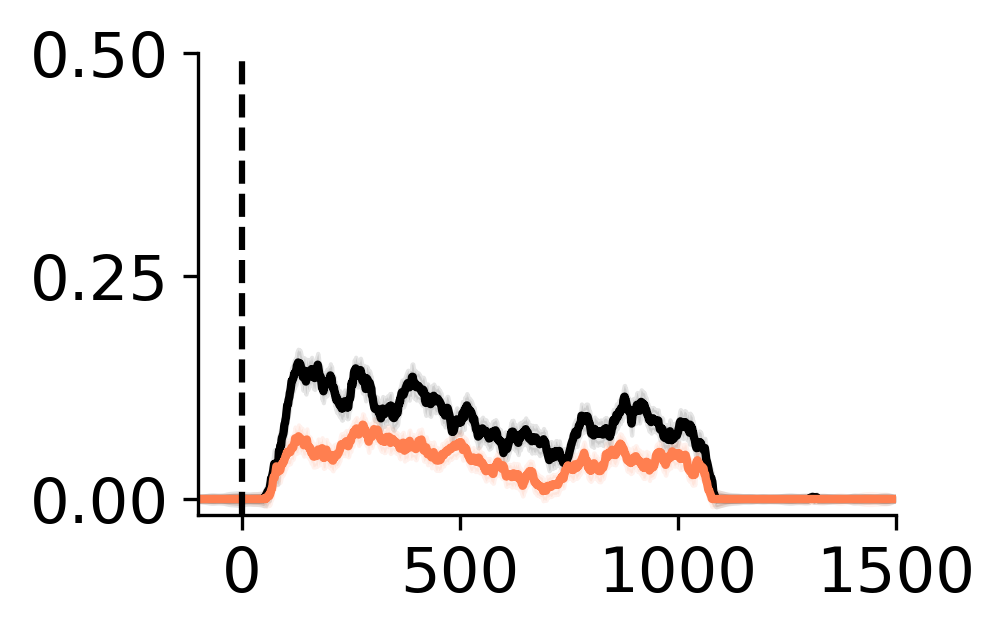

In [391]:

PreData = PreDOI_LowSF_Norm[PreDOI_Grating_Responsive.astype(bool),1400:3000]
PostData = PostDOI_LowSF_Norm[PreDOI_Grating_Responsive.astype(bool),1400:3000]

#Mean average grating response before and after DOI
Av_PSTH_PreDOI_Mean = np.nanmedian(np.squeeze(PreData),axis=0)
Av_PSTH_PostDOI_Mean = np.nanmedian(np.squeeze(PostData),axis=0)

#STE average Grating Response before and after DOI
Av_PSTH_PreDOI_STE = np.nanstd(np.squeeze(PreData),axis=0)/sqrt(len(PreData))
Av_PSTH_PostDOI_STE = np.nanstd(np.squeeze(PostData),axis=0)/sqrt(len(PostData))



# Plotting mean and standard deviation for each group before DOI
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreDOI_Mean, Av_PSTH_PostDOI_Mean],
                                                [Av_PSTH_PreDOI_STE, Av_PSTH_PostDOI_STE],
                                                ['black','coral'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'DOI_AverageNormalizedGratingResponse_MedSF.eps'),dpi=300)

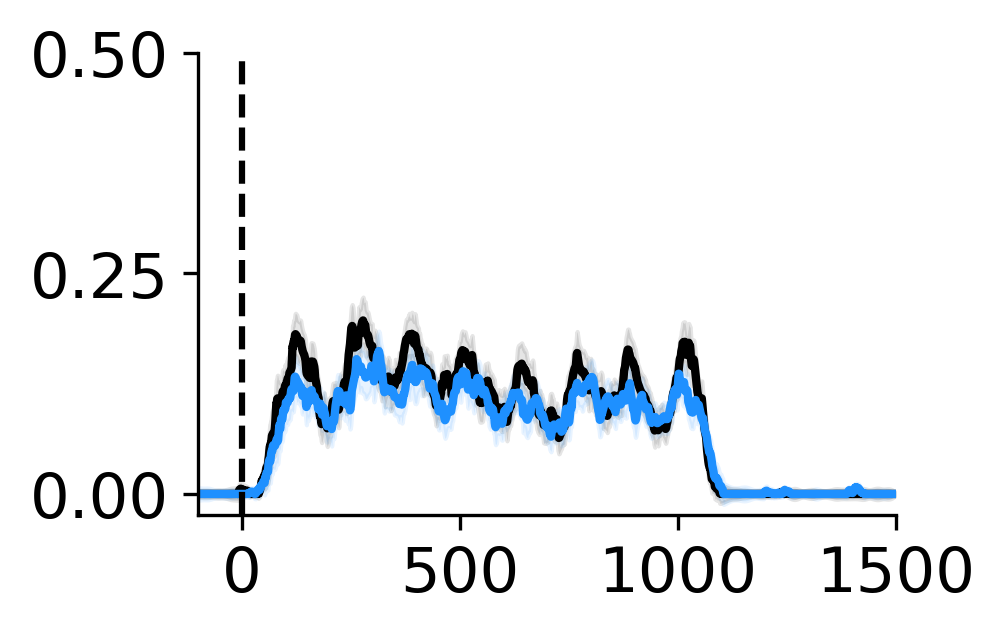

In [394]:
PreData = PreSaline_LowSF_Norm[PreSaline_Grating_Responsive.astype(bool),1400:3000]
PostData = PostSaline_LowSF_Norm[PreSaline_Grating_Responsive.astype(bool),1400:3000]

#Mean average grating response before and after Saline
Av_PSTH_PreSaline_Mean = np.nanmedian(np.squeeze(PreData),axis=0)
Av_PSTH_PostSaline_Mean = np.nanmedian(np.squeeze(PostData),axis=0)

#STE average Grating Response before and after Saline
Av_PSTH_PreSaline_STE = np.nanstd(np.squeeze(PreData),axis=0)/sqrt(len(PreData))
Av_PSTH_PostSaline_STE = np.nanstd(np.squeeze(PostData),axis=0)/sqrt(len(PostData))



# Plotting mean and standard deviation for each group before Saline
fig, axs=plt.subplots(1,1,figsize=(3,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreSaline_Mean, Av_PSTH_PostSaline_Mean],
                                                [Av_PSTH_PreSaline_STE, Av_PSTH_PostSaline_STE],
                                                ['black','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([100, 600, 1100, 1600],labels=[0,500,1000,1500])
plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-.05,.5)  # Setting y-axis limit
plt.xlim(0,1600)
plt.axvline(x=100, color='black', linestyle='--')  # Vertical dashed line at x=0

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'Saline_AverageNormalizedGratingResponse_MedSF.eps'),dpi=300)

(0.0, 0.5)

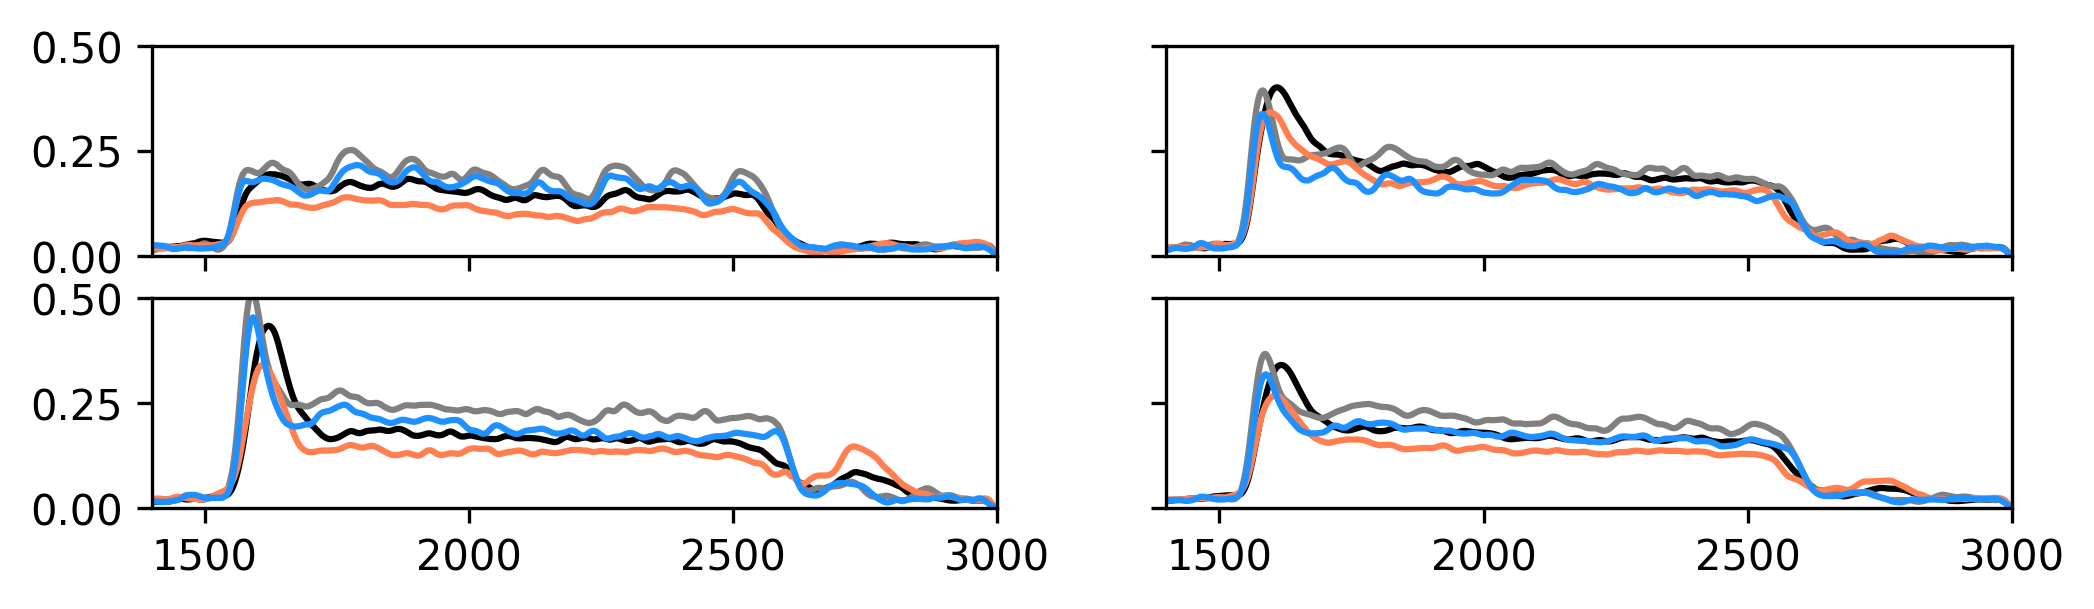

In [277]:

fig, axs=plt.subplots(2,2,figsize=(8,2), dpi=300,sharey = True, sharex = True)
axs = axs.ravel()

axs[0].plot(np.nanmean(PreDOI_LowSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[1].plot(np.nanmean(PreDOI_MedSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[2].plot(np.nanmean(PreDOI_HighSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[3].plot(np.nanmean(PreDOI_All_Norm,axis=0),color = 'black')


axs[0].plot(np.nanmean(PreSaline_LowSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[1].plot(np.nanmean(PreSaline_MedSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[2].plot(np.nanmean(PreSaline_HighSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[3].plot(np.nanmean(PreSaline_All_Norm,axis=0),color = 'grey')

axs[0].plot(np.nanmean(PostDOI_LowSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'coral')
axs[1].plot(np.nanmean(PostDOI_MedSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'coral')
axs[2].plot(np.nanmean(PostDOI_HighSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'coral')
axs[3].plot(np.nanmean(PostDOI_All_Norm,axis=0),color = 'coral')


axs[0].plot(np.nanmean(PostSaline_LowSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'dodgerblue')
axs[1].plot(np.nanmean(PostSaline_MedSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'dodgerblue')
axs[2].plot(np.nanmean(PostSaline_HighSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'dodgerblue')
axs[3].plot(np.nanmean(PostSaline_All_Norm,axis=0),color = 'dodgerblue')

axs[0].set_xlim(1400,3000)
axs[0].set_ylim(0,.5)


(0.0, 0.6)

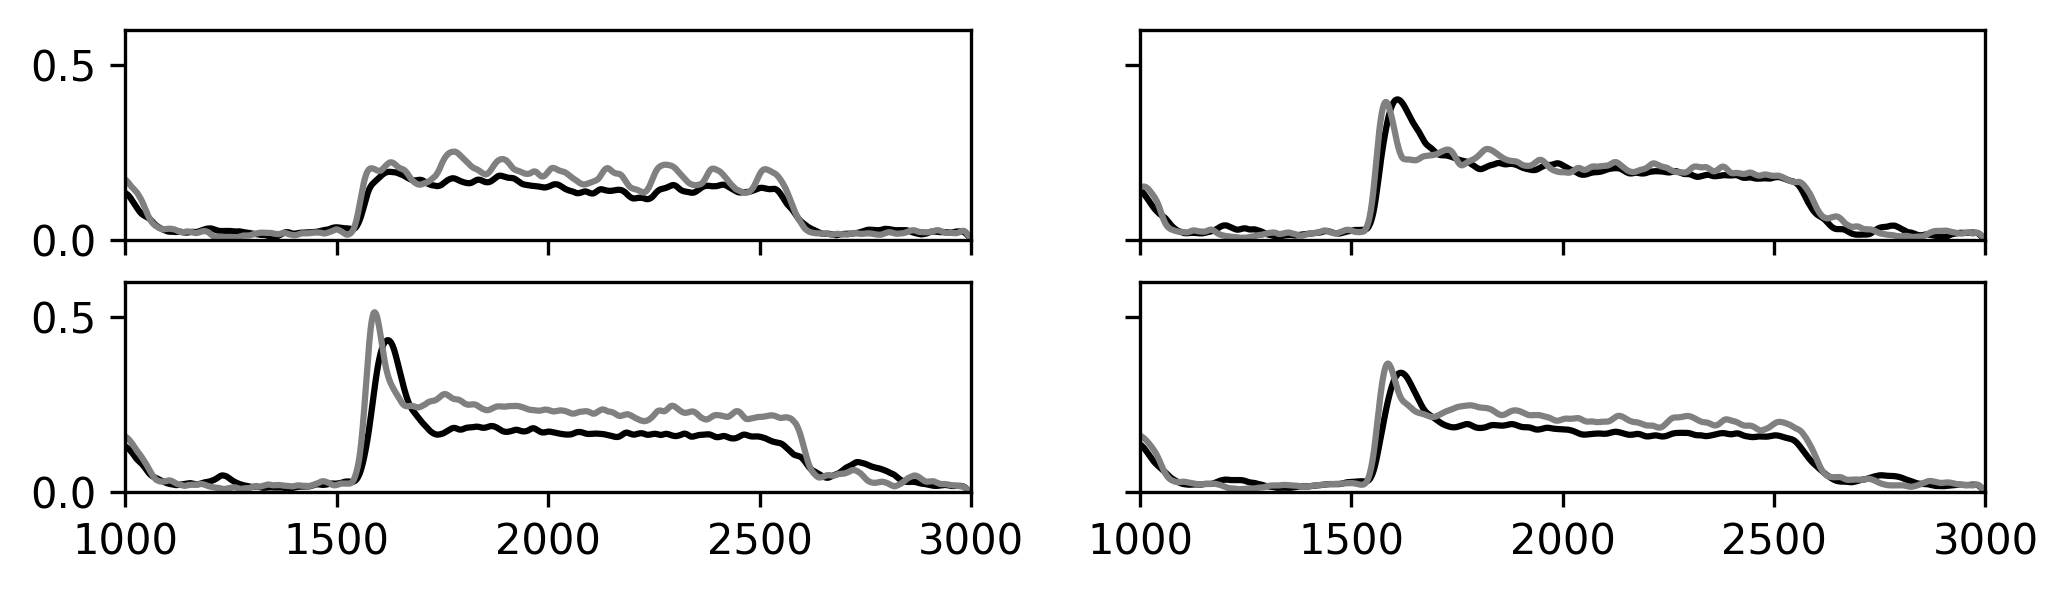

In [218]:

fig, axs=plt.subplots(2,2,figsize=(8,2), dpi=300,sharey = True, sharex = True)
axs = axs.ravel()

axs[0].plot(np.nanmean(PreDOI_LowSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[1].plot(np.nanmean(PreDOI_MedSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[2].plot(np.nanmean(PreDOI_HighSF_Norm[PreDOI_Grating_Responsive.astype(bool)],axis=0),color = 'black')
axs[3].plot(np.nanmean(PreDOI_All_Norm,axis=0),color = 'black')

axs[0].plot(np.nanmean(PreSaline_LowSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[1].plot(np.nanmean(PreSaline_MedSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[2].plot(np.nanmean(PreSaline_HighSF_Norm[PreSaline_Grating_Responsive.astype(bool)],axis=0),color = 'grey')
axs[3].plot(np.nanmean(PreSaline_All_Norm,axis=0),color = 'grey')

axs[0].set_xlim(1000,3000)
axs[0].set_ylim(0,.6)

In [281]:
np.shape(PostDOI_LowSF_PSTH_Baselined)

(374, 3001)

In [411]:

DOI_LowSF_ModIDX = (np.nanmax(PostDOI_LowSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreDOI_LowSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostDOI_LowSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreDOI_LowSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))
DOI_MedSF_ModIDX = (np.nanmax(PostDOI_MedSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreDOI_MedSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostDOI_MedSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreDOI_MedSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))
DOI_HighSF_ModIDX = (np.nanmax(PostDOI_HighSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreDOI_HighSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostDOI_HighSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreDOI_HighSF_PSTH_Baselined[PreDOI_Grating_Responsive.astype(bool),1500:2500],axis=1))


Saline_LowSF_ModIDX = (np.nanmax(PostSaline_LowSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreSaline_LowSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostSaline_LowSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreSaline_LowSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))
Saline_MedSF_ModIDX = (np.nanmax(PostSaline_MedSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreSaline_MedSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostSaline_MedSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreSaline_MedSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))
Saline_HighSF_ModIDX = (np.nanmax(PostSaline_HighSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)-np.nanmax(PreSaline_HighSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))/(np.nanmax(PostSaline_HighSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1)+np.nanmax(PreSaline_HighSF_PSTH_Baselined[PreSaline_Grating_Responsive.astype(bool),1500:2500],axis=1))


In [412]:
DOI_LowSF_ModIDX = np.delete(DOI_LowSF_ModIDX,135)
DOI_MedSF_ModIDX = np.delete(DOI_MedSF_ModIDX,135)
DOI_HighSF_ModIDX = np.delete(DOI_HighSF_ModIDX,135)

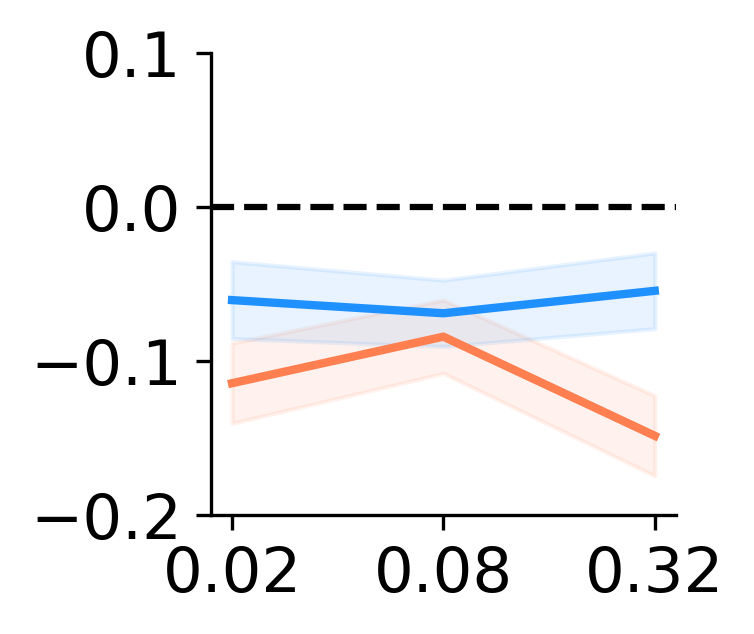

In [433]:
DOI_ModIDX_SFs = [DOI_LowSF_ModIDX,DOI_MedSF_ModIDX,DOI_HighSF_ModIDX]
Saline_ModIDX_SFs = [Saline_LowSF_ModIDX,Saline_MedSF_ModIDX,Saline_HighSF_ModIDX]


#Mean average grating response before and after Saline
Av_PSTH_PreSaline_Mean = np.nanmean(DOI_ModIDX_SFs,axis=1)
Av_PSTH_PostSaline_Mean = np.nanmean(Saline_ModIDX_SFs,axis=1)

#STE average Grating Response before and after Saline
Av_PSTH_PreSaline_STE = np.nanstd(DOI_ModIDX_SFs,axis=1)/sqrt(np.shape(DOI_ModIDX_SFs)[1])
Av_PSTH_PostSaline_STE = np.nanstd(Saline_ModIDX_SFs,axis=1)/sqrt(np.shape(Saline_ModIDX_SFs)[1])



# Plotting mean and standard deviation for each group before Saline
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreSaline_Mean, Av_PSTH_PostSaline_Mean],
                                                [Av_PSTH_PreSaline_STE, Av_PSTH_PostSaline_STE],
                                                ['coral','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([0,1,2],labels=[0.02,0.08,.32])
#plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
plt.ylim(-.2,.1)  # Setting y-axis limit
plt.axhline(0,color = 'black',linestyle='--')

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'ModIdX_BySF.eps'),dpi=300)


In [ ]:
DOI_ModIDX_SFs = [np.abs(DOI_LowSF_ModIDX),np.abs(DOI_MedSF_ModIDX),np.abs(DOI_HighSF_ModIDX)]
Saline_ModIDX_SFs = [np.abs(Saline_LowSF_ModIDX),np.abs(Saline_MedSF_ModIDX),np.abs(Saline_HighSF_ModIDX)]


#Mean average grating response before and after Saline
Av_PSTH_PreSaline_Mean = np.nanmean(DOI_ModIDX_SFs,axis=1)
Av_PSTH_PostSaline_Mean = np.nanmean(Saline_ModIDX_SFs,axis=1)

#STE average Grating Response before and after Saline
Av_PSTH_PreSaline_STE = np.nanstd(DOI_ModIDX_SFs,axis=1)/sqrt(np.shape(DOI_ModIDX_SFs)[1])
Av_PSTH_PostSaline_STE = np.nanstd(Saline_ModIDX_SFs,axis=1)/sqrt(np.shape(Saline_ModIDX_SFs)[1])



# Plotting mean and standard deviation for each group before Saline
fig, axs=plt.subplots(1,1,figsize=(2,2), dpi=300)
for group_mean, group_std, color, label in zip([Av_PSTH_PreSaline_Mean, Av_PSTH_PostSaline_Mean],
                                                [Av_PSTH_PreSaline_STE, Av_PSTH_PostSaline_STE],
                                                ['coral','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.xticks(fontsize=15) 
plt.xticks([0,1,2],labels=[0.02,0.08,.32])
#plt.yticks([0,.25,.5])
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-.2,.1)  # Setting y-axis limit
plt.axhline(0,color = 'black',linestyle='--')

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'ModIdX_BySF.eps'),dpi=300)


In [435]:
from scipy import stats
t_stat, p_value = stats.ranksums(DOI_LowSF_ModIDX, Saline_LowSF_ModIDX,alternative = 'less')
print(t_stat, 't - low sf')
print(p_value, 'p - low sf')

from scipy import stats
t_stat, p_value = stats.ranksums(DOI_MedSF_ModIDX, Saline_MedSF_ModIDX,alternative = 'less')
print(t_stat, 't - medium sf')
print(p_value, 'p - medium sf')

from scipy import stats
t_stat, p_value = stats.ranksums(DOI_HighSF_ModIDX, Saline_HighSF_ModIDX,alternative = 'less')
print(t_stat, 't - high sf')
print(p_value, 'p - high sf')

-1.2855190012242317 t - low sf
0.09930549058400767 p - low sf
0.10303778254087353 t - medium sf
0.5410335078033074 p - medium sf
-2.3796821205868413 t - high sf
0.008663789151447743 p - high sf


In [295]:

#Collecting Baseline Subtracted Grating Responses
PSTH_Pre = np.stack(GratingData_DOI['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_DOI['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs
 
#only analyzing cells responsive to both conditions
PSTH_Pre = PSTH_Pre[DOI_Grating_ResponsivetoBoth.astype(bool)]
PSTH_Post = PSTH_Post[DOI_Grating_ResponsivetoBoth.astype(bool)]

#Averaging over orientation 
PSTH_Pre_OriAv_DOI = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_DOI = np.nanmean(PSTH_Post,axis=3)
PSTH_Pre_OriAv_DOI_Temp = PSTH_Pre_OriAv_DOI.copy()
PSTH_Pre_OriAv_DOI_Temp[PSTH_Pre_OriAv_DOI_Temp<0] = 0
PSTH_Post_OriAv_DOI_Temp = PSTH_Post_OriAv_DOI.copy()
PSTH_Post_OriAv_DOI_Temp[PSTH_Post_OriAv_DOI_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_DOI = np.nanmean(PSTH_Pre_OriAv_DOI_Temp[:,:,:,1525:2500],axis= 3)
Post_MeanResponse_DOI = np.nanmean(PSTH_Post_OriAv_DOI_Temp[:,:,:,1525:2500],axis= 3)

#setting up variables for the loop 
PrefTF = np.zeros([len(PSTH_Pre),2])*np.nan
PrefSF = np.zeros([len(PSTH_Pre),2])*np.nan

WeightedSF_DOI = np.zeros([len(PSTH_Pre),2])*np.nan
WeightedTF_DOI = np.zeros([len(PSTH_Pre),2])*np.nan

PreDOI_Pref_Resp = np.zeros([len(PSTH_Pre),3001])
PostDOI_Pref_Resp = np.zeros([len(PSTH_Pre),3001])

SF_Tuning_PreDOI = np.zeros([len(PSTH_Pre),3])
SF_Tuning_PostDOI = np.zeros([len(PSTH_Pre),3])
TF_Tuning_PreDOI = np.zeros([len(PSTH_Pre),2])
TF_Tuning_PostDOI = np.zeros([len(PSTH_Pre),2])


for ii in list(range(0,len(PSTH_Pre))):
    Pre_Resp = Pre_MeanResponse_DOI[ii]
    Pref_Resp_Pre_Idx = np.where(Pre_Resp == np.nanmax(Pre_Resp))
    PrefTF[ii,0] = Pref_Resp_Pre_Idx[0]
    PrefSF[ii,0] = Pref_Resp_Pre_Idx[1]
    PreDOI_Pref_Resp[ii,:] = PSTH_Pre_OriAv_DOI[ii,int(PrefTF[ii,0]),int(PrefSF[ii,0]),:]

    Post_Resp = Post_MeanResponse_DOI[ii]
    Pref_Resp_Post_Idx = np.where(Post_Resp == np.nanmax(Post_Resp))
    PrefTF[ii,1] = Pref_Resp_Post_Idx[0]
    PrefSF[ii,1] = Pref_Resp_Post_Idx[1]
    PostDOI_Pref_Resp[ii,:] = PSTH_Post_OriAv_DOI[ii,int(PrefTF[ii,1]),int(PrefSF[ii,1]),:]


    WeightedSF_DOI[ii,0] = ((Pre_Resp[int(PrefTF[ii,0]),0]*0.02) + (Pre_Resp[int(PrefTF[ii,0]),1]*0.08) + (Pre_Resp[int(PrefTF[ii,0]),2]*0.32))/np.sum(Pre_Resp[int(PrefTF[ii,0]),:])
    SF_Tuning_PreDOI[ii,:] = [Pre_Resp[int(PrefTF[ii,0]),0],Pre_Resp[int(PrefTF[ii,0]),1],Pre_Resp[int(PrefTF[ii,0]),2]]

    WeightedSF_DOI[ii,1] = ((Post_Resp[int(PrefTF[ii,1]),0]*0.02) + (Post_Resp[int(PrefTF[ii,1]),1]*0.08) + (Post_Resp[int(PrefTF[ii,1]),2]*.32))/np.sum(Post_Resp[int(PrefTF[ii,1]),:])
    SF_Tuning_PostDOI[ii,:] = [Post_Resp[int(PrefTF[ii,1]),0],Post_Resp[int(PrefTF[ii,1]),1],Post_Resp[int(PrefTF[ii,1]),2]]

    WeightedTF_DOI[ii,0] = ((Pre_Resp[0,int(PrefSF[ii,0])]*2) + (Pre_Resp[1,int(PrefSF[ii,0])]*8))/ np.sum(Pre_Resp[:,int(PrefSF[ii,0])])
    TF_Tuning_PreDOI[ii,:] = [Pre_Resp[0,int(PrefSF[ii,0])],Pre_Resp[1,int(PrefSF[ii,0])]]

    WeightedTF_DOI[ii,1] = ((Post_Resp[0,int(PrefSF[ii,1])]*2) + (Post_Resp[1,int(PrefSF[ii,1])]*8))/ np.sum(Post_Resp[:,int(PrefSF[ii,1])])
    TF_Tuning_PostDOI[ii,:] = [Post_Resp[0,int(PrefSF[ii,1])],Post_Resp[1,int(PrefSF[ii,1])]]

In [296]:
PreDOI_Labels_Lim = PreDOI_Labels[PreDOI_Grating_Responsive.astype(bool)]
PreDOI_Unresp = PreDOI_Labels_Lim == 0
PreDOI_Biphasic = PreDOI_Labels_Lim == 1
PreDOI_Late = PreDOI_Labels_Lim == 2
PreDOI_Early = PreDOI_Labels_Lim == 3
PreDOI_Negative = PreDOI_Labels_Lim == 4


IndexError: boolean index did not match indexed array along dimension 0; dimension is 374 but corresponding boolean dimension is 190

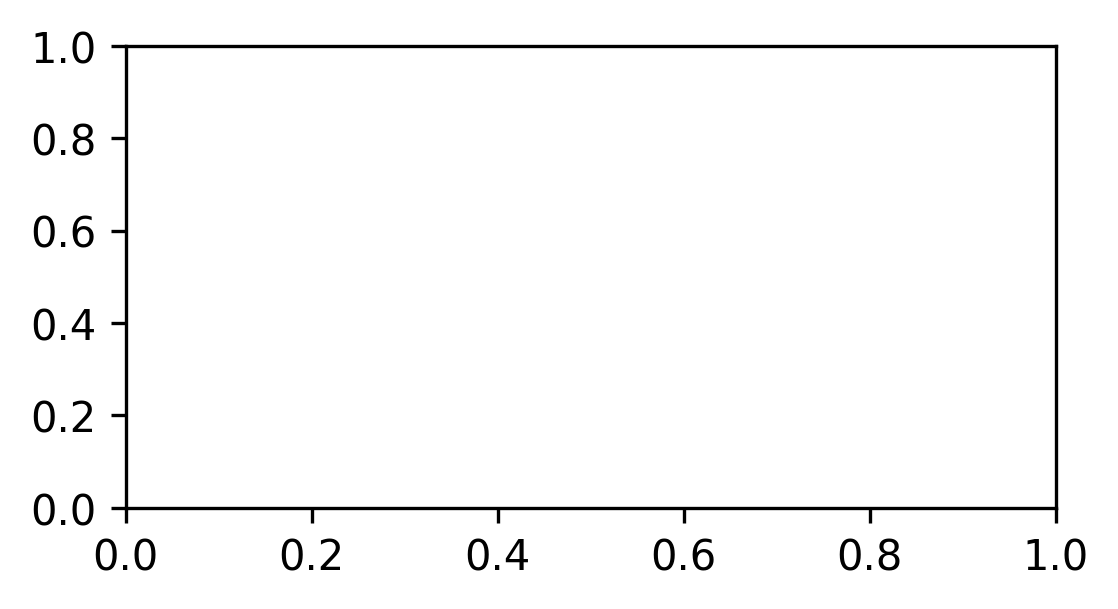

In [312]:
PSTH_Pre = np.stack(GratingData_DOI['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_DOI['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = PSTH_Pre[PreDOI_Grating_Responsive.astype(bool)]
PSTH_Post = PSTH_Post[PreDOI_Grating_Responsive.astype(bool)]

#Averaging over orientation 
PSTH_Pre_OriAv_DOI = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_DOI = np.nanmean(PSTH_Post,axis=3)
PSTH_Pre_OriAv_DOI_Temp = PSTH_Pre_OriAv_DOI.copy()
PSTH_Pre_OriAv_DOI_Temp[PSTH_Pre_OriAv_DOI_Temp<0] = 0
PSTH_Post_OriAv_DOI_Temp = PSTH_Post_OriAv_DOI.copy()
PSTH_Post_OriAv_DOI_Temp[PSTH_Post_OriAv_DOI_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_DOI = np.nanmean(np.abs(PSTH_Pre_OriAv_DOI_Temp[:,:,:,1525:2500]),axis= 3)
Post_MeanResponse_DOI = np.nanmean(np.abs(PSTH_Post_OriAv_DOI_Temp[:,:,:,1525:2500]),axis= 3)

PreDOI_MaxResp = np.nanmax(np.nanmax(Pre_MeanResponse_DOI,axis=1),axis=1)
PostDOI_MaxResp = np.nanmax(np.nanmax(Post_MeanResponse_DOI,axis=1),axis=1) 

PreDOI_Pref_Resp[PreDOI_Pref_Resp<0] = 0

PostDOI_Pref_Resp[PostDOI_Pref_Resp<0] = 0

#PreDOI_MaxResp = np.nanmax(PreDOI_Pref_Resp[:,1500:1750],axis=1)
#PostDOI_MaxResp = np.nanmax(PostDOI_Pref_Resp[:,1500:1750],axis=1)

MxMx = np.nanmax([PreDOI_MaxResp,PostDOI_MaxResp],axis=0)


#PreDOI_MaxResp = PreDOI_MaxResp/MxMx
#PostDOI_MaxResp = PostDOI_MaxResp/MxMx

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(PreDOI_MaxResp[PreDOI_Early]),yerr = np.nanstd(PreDOI_MaxResp[PreDOI_Early])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(PostDOI_MaxResp[PreDOI_Early]),yerr = np.nanstd(PostDOI_MaxResp[PreDOI_Early])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),PreDOI_MaxResp[PreDOI_Early],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),PostDOI_MaxResp[PreDOI_Early],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(PreDOI_MaxResp[PreDOI_Late]),yerr = np.nanstd(PreDOI_MaxResp[PreDOI_Late])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(PostDOI_MaxResp[PreDOI_Late]),yerr = np.nanstd(PostDOI_MaxResp[PreDOI_Late])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),PreDOI_MaxResp[PreDOI_Late],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),PostDOI_MaxResp[PreDOI_Late],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(PreDOI_MaxResp[PreDOI_Biphasic]),yerr = np.nanstd(PreDOI_MaxResp[PreDOI_Biphasic])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(PostDOI_MaxResp[PreDOI_Biphasic]),yerr = np.nanstd(PostDOI_MaxResp[PreDOI_Biphasic])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),PreDOI_MaxResp[PreDOI_Biphasic],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),PostDOI_MaxResp[PreDOI_Biphasic],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(PreDOI_MaxResp[PreDOI_Negative]),yerr = np.nanstd(PreDOI_MaxResp[PreDOI_Negative])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(PostDOI_MaxResp[PreDOI_Negative]),yerr = np.nanstd(PostDOI_MaxResp[PreDOI_Negative])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),PreDOI_MaxResp[PreDOI_Negative],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),PostDOI_MaxResp[PreDOI_Negative],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.xticks(ticks = [2.5,5.5,8.5,11.5])
plt.ylim(0,20)

In [301]:
PreSaline_Labels_Lim = PreSaline_Labels[PreSaline_Grating_Responsive.astype(bool)]
PreSaline_Unresp = PreSaline_Labels_Lim == 0
PreSaline_Biphasic = PreSaline_Labels_Lim == 1
PreSaline_Late = PreSaline_Labels_Lim == 2
PreSaline_Early = PreSaline_Labels_Lim == 3
PreSaline_Negative = PreSaline_Labels_Lim == 4


([<matplotlib.axis.XTick at 0x2d308ea92b0>,
 [Text(2.5, 0, '2.5'),
  Text(5.5, 0, '5.5'),
  Text(8.5, 0, '8.5'),
  Text(11.5, 0, '11.5')])

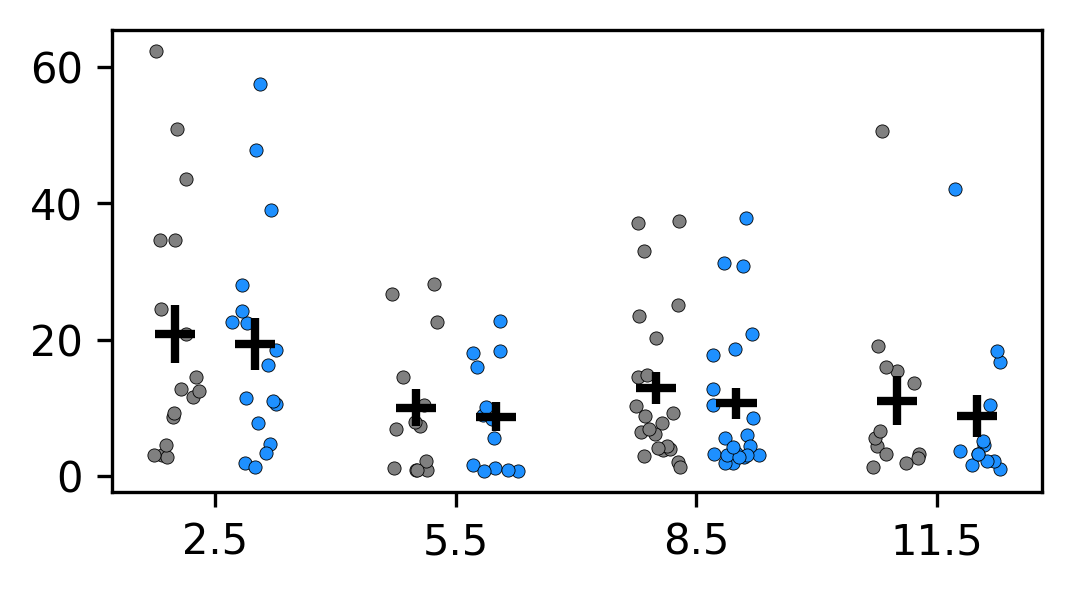

In [302]:
PSTH_Pre = np.stack(GratingData_Saline['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_Saline['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = PSTH_Pre[PreSaline_Grating_Responsive.astype(bool)]
PSTH_Post = PSTH_Post[PreSaline_Grating_Responsive.astype(bool)]
#Averaging over orientation 
PSTH_Pre_OriAv_Saline = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_Saline = np.nanmean(PSTH_Post,axis=3)
PSTH_Pre_OriAv_Saline_Temp = PSTH_Pre_OriAv_Saline.copy()
PSTH_Pre_OriAv_Saline_Temp[PSTH_Pre_OriAv_Saline_Temp<0] = 0
PSTH_Post_OriAv_Saline_Temp = PSTH_Post_OriAv_Saline.copy()
PSTH_Post_OriAv_Saline_Temp[PSTH_Post_OriAv_Saline_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_Saline = np.nanmean(np.abs(PSTH_Pre_OriAv_Saline_Temp[:,:,:,1525:2500]),axis= 3)
Post_MeanResponse_Saline = np.nanmean(np.abs(PSTH_Post_OriAv_Saline_Temp[:,:,:,1525:2500]),axis= 3)

PreSaline_MaxResp = np.nanmax(np.nanmax(Pre_MeanResponse_Saline,axis=1),axis=1)
PostSaline_MaxResp = np.nanmax(np.nanmax(Post_MeanResponse_Saline,axis=1),axis=1) 

PreSaline_Pref_Resp[PreSaline_Pref_Resp<0] = 0
PostSaline_Pref_Resp[PostSaline_Pref_Resp<0] = 0

#PreSaline_MaxResp = np.nanmax(PreSaline_Pref_Resp[:,1500:1750],axis=1)
#PostSaline_MaxResp = np.nanmax(PostSaline_Pref_Resp[:,1500:1750],axis=1)

MxMx = np.nanmax([PreSaline_MaxResp,PostSaline_MaxResp],axis=0)

#PreSaline_MaxResp = PreSaline_MaxResp/MxMx
#PostSaline_MaxResp = PostSaline_MaxResp/MxMx

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(PreSaline_MaxResp[PreSaline_Early]),yerr = np.nanstd(PreSaline_MaxResp[PreSaline_Early])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(PostSaline_MaxResp[PreSaline_Early]),yerr = np.nanstd(PostSaline_MaxResp[PreSaline_Early])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreSaline_Early),.3),PreSaline_MaxResp[PreSaline_Early],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),PostSaline_MaxResp[PreSaline_Early],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(PreSaline_MaxResp[PreSaline_Late]),yerr = np.nanstd(PreSaline_MaxResp[PreSaline_Late])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(PostSaline_MaxResp[PreSaline_Late]),yerr = np.nanstd(PostSaline_MaxResp[PreSaline_Late])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreSaline_Late),.3),PreSaline_MaxResp[PreSaline_Late],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),PostSaline_MaxResp[PreSaline_Late],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(PreSaline_MaxResp[PreSaline_Biphasic]),yerr = np.nanstd(PreSaline_MaxResp[PreSaline_Biphasic])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(PostSaline_MaxResp[PreSaline_Biphasic]),yerr = np.nanstd(PostSaline_MaxResp[PreSaline_Biphasic])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreSaline_Biphasic),.3),PreSaline_MaxResp[PreSaline_Biphasic],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),PostSaline_MaxResp[PreSaline_Biphasic],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(PreSaline_MaxResp[PreSaline_Negative]),yerr = np.nanstd(PreSaline_MaxResp[PreSaline_Negative])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(PostSaline_MaxResp[PreSaline_Negative]),yerr = np.nanstd(PostSaline_MaxResp[PreSaline_Negative])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreSaline_Negative),.3),PreSaline_MaxResp[PreSaline_Negative],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),PostSaline_MaxResp[PreSaline_Negative],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.xticks(ticks = [2.5,5.5,8.5,11.5])

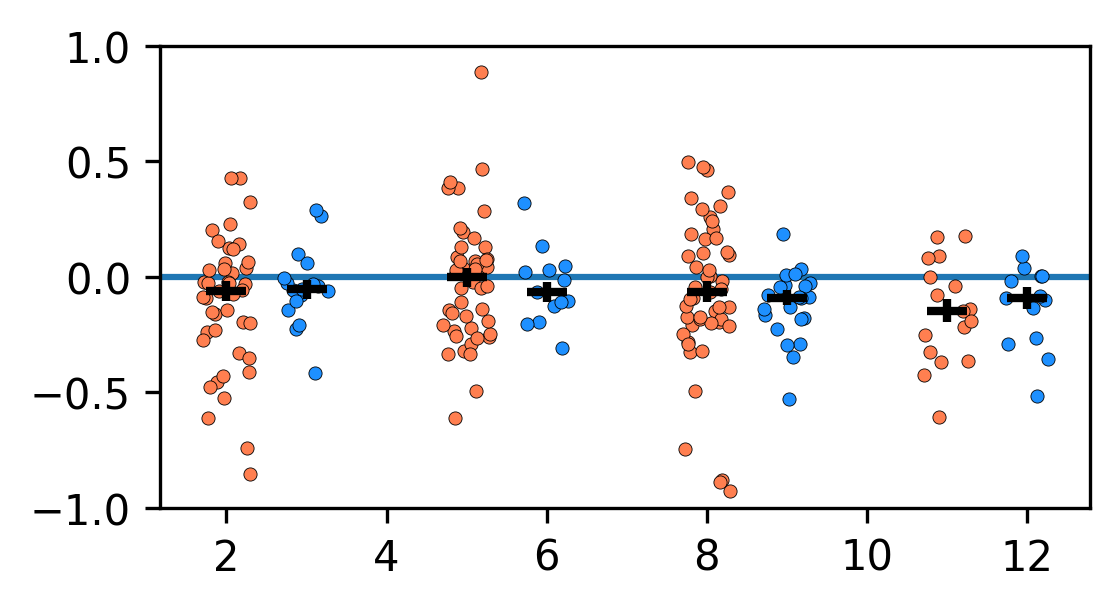

In [303]:
DOI_Max_ModIdX = (PostDOI_MaxResp-PreDOI_MaxResp)/(PostDOI_MaxResp+PreDOI_MaxResp)
Saline_Max_ModIdX = (PostSaline_MaxResp-PreSaline_MaxResp)/(PostSaline_MaxResp+PreSaline_MaxResp)

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmedian(DOI_Max_ModIdX[PreDOI_Early]),yerr = np.nanstd(DOI_Max_ModIdX[PreDOI_Early])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmedian(Saline_Max_ModIdX[PreSaline_Early]),yerr = np.nanstd(Saline_Max_ModIdX[PreSaline_Early])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),DOI_Max_ModIdX[PreDOI_Early],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),Saline_Max_ModIdX[PreSaline_Early],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmedian(DOI_Max_ModIdX[PreDOI_Late]),yerr = np.nanstd(DOI_Max_ModIdX[PreDOI_Late])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmedian(Saline_Max_ModIdX[PreSaline_Late]),yerr = np.nanstd(Saline_Max_ModIdX[PreSaline_Late])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),DOI_Max_ModIdX[PreDOI_Late],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),Saline_Max_ModIdX[PreSaline_Late],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmedian(DOI_Max_ModIdX[PreDOI_Biphasic]),yerr = np.nanstd(DOI_Max_ModIdX[PreDOI_Biphasic])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmedian(Saline_Max_ModIdX[PreSaline_Biphasic]),yerr = np.nanstd(Saline_Max_ModIdX[PreSaline_Biphasic])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),DOI_Max_ModIdX[PreDOI_Biphasic],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),Saline_Max_ModIdX[PreSaline_Biphasic],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmedian(DOI_Max_ModIdX[PreDOI_Negative]),yerr = np.nanstd(DOI_Max_ModIdX[PreDOI_Negative])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmedian(Saline_Max_ModIdX[PreSaline_Negative]),yerr = np.nanstd(Saline_Max_ModIdX[PreSaline_Negative])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),DOI_Max_ModIdX[PreDOI_Negative],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),Saline_Max_ModIdX[PreSaline_Negative],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim(-1,1)
plt.axhline(0)

In [313]:
PSTH_Pre = np.stack(GratingData_DOI['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_DOI['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = PSTH_Pre#[PreDOI_Grating_Responsive.astype(bool)]
PSTH_Post = PSTH_Post#[PreDOI_Grating_Responsive.astype(bool)]

#Averaging over orientation 
PSTH_Pre_OriAv_DOI = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_DOI = np.nanmean(PSTH_Post,axis=3)
PSTH_Pre_OriAv_DOI_Temp = PSTH_Pre_OriAv_DOI.copy()
PSTH_Pre_OriAv_DOI_Temp[PSTH_Pre_OriAv_DOI_Temp<0] = 0
PSTH_Post_OriAv_DOI_Temp = PSTH_Post_OriAv_DOI.copy()
PSTH_Post_OriAv_DOI_Temp[PSTH_Post_OriAv_DOI_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_DOI = np.nanmean(np.abs(PSTH_Pre_OriAv_DOI_Temp[:,:,:,1525:2500]),axis= 3)
Post_MeanResponse_DOI = np.nanmean(np.abs(PSTH_Post_OriAv_DOI_Temp[:,:,:,1525:2500]),axis= 3)

PreDOI_MaxResp = np.nanmax(np.nanmax(Pre_MeanResponse_DOI,axis=1),axis=1)
PostDOI_MaxResp = np.nanmax(np.nanmax(Post_MeanResponse_DOI,axis=1),axis=1) 

DOI_Max_ModIdX = (PostDOI_MaxResp-PreDOI_MaxResp)/(PostDOI_MaxResp+PreDOI_MaxResp)
#Saline_Max_ModIdX = (PostSaline_MaxResp-PreSaline_MaxResp)/(PostSaline_MaxResp+PreSaline_MaxResp)



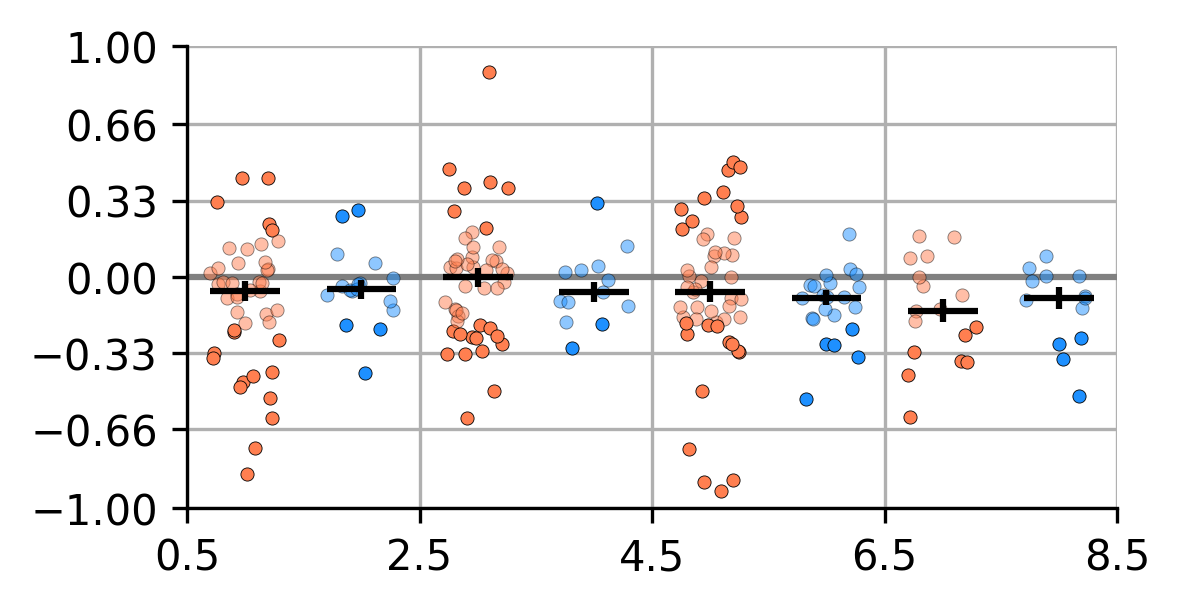

In [308]:
thresh = .2
col_adj = [100,4,2,0,6]

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)

plt.errorbar(1,np.nanmedian(DOI_Max_ModIdX[PreDOI_Labels_Lim == 3]),xerr=.3,yerr=np.nanstd(DOI_Max_ModIdX[PreDOI_Labels_Lim == 3])/sqrt(np.sum(PreDOI_Labels_Lim == 3)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(2,np.nanmedian(Saline_Max_ModIdX[PreSaline_Labels_Lim == 3]),xerr=.3,yerr=np.nanstd(Saline_Max_ModIdX[PreSaline_Labels_Lim == 3])/sqrt(np.sum(PreSaline_Labels_Lim == 3)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(3,np.nanmedian(DOI_Max_ModIdX[PreDOI_Labels_Lim == 2]),xerr=.3,yerr=np.nanstd(DOI_Max_ModIdX[PreDOI_Labels_Lim == 2])/sqrt(np.sum(PreDOI_Labels_Lim == 2)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(4,np.nanmedian(Saline_Max_ModIdX[PreSaline_Labels_Lim == 2]),xerr=.3,yerr=np.nanstd(Saline_Max_ModIdX[PreSaline_Labels_Lim == 2])/sqrt(np.sum(PreSaline_Labels_Lim == 2)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(5,np.nanmedian(DOI_Max_ModIdX[PreDOI_Labels_Lim == 1]),xerr=.3,yerr=np.nanstd(DOI_Max_ModIdX[PreDOI_Labels_Lim == 1])/sqrt(np.sum(PreDOI_Labels_Lim == 1)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(6,np.nanmedian(Saline_Max_ModIdX[PreSaline_Labels_Lim == 1]),xerr=.3,yerr=np.nanstd(Saline_Max_ModIdX[PreSaline_Labels_Lim == 1])/sqrt(np.sum(PreSaline_Labels_Lim == 1)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(7,np.nanmedian(DOI_Max_ModIdX[PreDOI_Labels_Lim == 4]),xerr=.3,yerr=np.nanstd(DOI_Max_ModIdX[PreDOI_Labels_Lim == 4])/sqrt(np.sum(PreDOI_Labels_Lim == 4)),color = 'black', linewidth = 1.5,zorder = 8)
plt.errorbar(8,np.nanmedian(Saline_Max_ModIdX[PreSaline_Labels_Lim == 4]),xerr=.3,yerr=np.nanstd(Saline_Max_ModIdX[PreSaline_Labels_Lim == 4])/sqrt(np.sum(PreSaline_Labels_Lim == 4)),color = 'black', linewidth = 1.5,zorder = 8)

for ii in range(0,len(DOI_Max_ModIdX)):
    if  np.abs(DOI_Max_ModIdX[ii]) > thresh:
        plt.scatter(jitter(col_adj[PreDOI_Labels_Lim[ii]],1,.3), DOI_Max_ModIdX[ii], color = 'coral', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
    else:
        plt.scatter(jitter(col_adj[PreDOI_Labels_Lim[ii]],1,.3), DOI_Max_ModIdX[ii], color = 'coral', s=10,zorder = 7,edgecolor = 'black',linewidth=.2,alpha = .5)  

for ii in range(0,len(Saline_Max_ModIdX)):
    if  np.abs(Saline_Max_ModIdX[ii]) > thresh:
        plt.scatter(jitter(col_adj[PreSaline_Labels_Lim[ii]]+1,1,.3), Saline_Max_ModIdX[ii], color = 'dodgerblue', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
    else:
        plt.scatter(jitter(col_adj[PreSaline_Labels_Lim[ii]]+1,1,.3), Saline_Max_ModIdX[ii], color = 'dodgerblue', s=10,zorder = 7,edgecolor = 'black',linewidth=.2,alpha = .5) 
 
plt.grid(zorder = 8)
plt.xlim(.5,8.5)
plt.xticks(ticks= [.5,2.5,4.5,6.5,8.5])
plt.ylim(-1,.66)
plt.yticks(ticks= [-1,-.66,-.33,0,.33,.66,1])
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.axhline(0,linestyle='-',color = 'grey')
plt.gca().set_rasterized(True)


In [305]:

#Collecting Baseline Subtracted Grating Responses
PSTH_Pre = np.stack(GratingData_Saline['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_Saline['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs
 
#only analyzing cells responsive to both conditions
PSTH_Pre = PSTH_Pre[Saline_Grating_ResponsivetoBoth.astype(bool)]
PSTH_Post = PSTH_Post[Saline_Grating_ResponsivetoBoth.astype(bool)]

#Averaging over orientation 
PSTH_Pre_OriAv_Saline = np.nanmean(PSTH_Pre,axis=3)
PSTH_Post_OriAv_Saline = np.nanmean(PSTH_Post,axis=3)
PSTH_Pre_OriAv_Saline_Temp = PSTH_Pre_OriAv_Saline.copy()
PSTH_Pre_OriAv_Saline_Temp[PSTH_Pre_OriAv_Saline_Temp<0] = 0
PSTH_Post_OriAv_Saline_Temp = PSTH_Post_OriAv_Saline.copy()
PSTH_Post_OriAv_Saline_Temp[PSTH_Post_OriAv_Saline_Temp<0] = 0

#Generating Time Averaged Responses for Each Grating Response
Pre_MeanResponse_Saline = np.nanmean(PSTH_Pre_OriAv_Saline_Temp[:,:,:,1525:2500],axis= 3)
Post_MeanResponse_Saline = np.nanmean(PSTH_Post_OriAv_Saline_Temp[:,:,:,1525:2500],axis= 3)

#setting up variables for the loop 
PrefTF = np.zeros([len(PSTH_Pre),2])*np.nan
PrefSF = np.zeros([len(PSTH_Pre),2])*np.nan

WeightedSF_Saline = np.zeros([len(PSTH_Pre),2])*np.nan
WeightedTF_Saline = np.zeros([len(PSTH_Pre),2])*np.nan

PreSaline_Pref_Resp = np.zeros([len(PSTH_Pre),3001])
PostSaline_Pref_Resp = np.zeros([len(PSTH_Pre),3001])

SF_Tuning_PreSaline = np.zeros([len(PSTH_Pre),3])
SF_Tuning_PostSaline = np.zeros([len(PSTH_Pre),3])
TF_Tuning_PreSaline = np.zeros([len(PSTH_Pre),2])
TF_Tuning_PostSaline = np.zeros([len(PSTH_Pre),2])


for ii in list(range(0,len(PSTH_Pre))):
    Pre_Resp = Pre_MeanResponse_Saline[ii]
    Pref_Resp_Pre_Idx = np.where(Pre_Resp == np.nanmax(Pre_Resp))
    PrefTF[ii,0] = Pref_Resp_Pre_Idx[0]
    PrefSF[ii,0] = Pref_Resp_Pre_Idx[1]
    PreSaline_Pref_Resp[ii,:] = PSTH_Pre_OriAv_Saline[ii,int(PrefTF[ii,0]),int(PrefSF[ii,0]),:]

    Post_Resp = Post_MeanResponse_Saline[ii]
    Pref_Resp_Post_Idx = np.where(Post_Resp == np.nanmax(Post_Resp))
    PrefTF[ii,1] = Pref_Resp_Post_Idx[0]
    PrefSF[ii,1] = Pref_Resp_Post_Idx[1]
    PostSaline_Pref_Resp[ii,:] = PSTH_Post_OriAv_Saline[ii,int(PrefTF[ii,1]),int(PrefSF[ii,1]),:]


    WeightedSF_Saline[ii,0] = ((Pre_Resp[int(PrefTF[ii,0]),0]*0.02) + (Pre_Resp[int(PrefTF[ii,0]),1]*0.08) + (Pre_Resp[int(PrefTF[ii,0]),2]*0.32))/np.sum(Pre_Resp[int(PrefTF[ii,0]),:])
    SF_Tuning_PreSaline[ii,:] = [Pre_Resp[int(PrefTF[ii,0]),0],Pre_Resp[int(PrefTF[ii,0]),1],Pre_Resp[int(PrefTF[ii,0]),2]]

    WeightedSF_Saline[ii,1] = ((Post_Resp[int(PrefTF[ii,1]),0]*0.02) + (Post_Resp[int(PrefTF[ii,1]),1]*0.08) + (Post_Resp[int(PrefTF[ii,1]),2]*.32))/np.sum(Post_Resp[int(PrefTF[ii,1]),:])
    SF_Tuning_PostSaline[ii,:] = [Post_Resp[int(PrefTF[ii,1]),0],Post_Resp[int(PrefTF[ii,1]),1],Post_Resp[int(PrefTF[ii,1]),2]]

    WeightedTF_Saline[ii,0] = ((Pre_Resp[0,int(PrefSF[ii,0])]*2) + (Pre_Resp[1,int(PrefSF[ii,0])]*8))/ np.sum(Pre_Resp[:,int(PrefSF[ii,0])])
    TF_Tuning_PreSaline[ii,:] = [Pre_Resp[0,int(PrefSF[ii,0])],Pre_Resp[1,int(PrefSF[ii,0])]]

    WeightedTF_Saline[ii,1] = ((Post_Resp[0,int(PrefSF[ii,1])]*2) + (Post_Resp[1,int(PrefSF[ii,1])]*8))/ np.sum(Post_Resp[:,int(PrefSF[ii,1])])
    TF_Tuning_PostSaline[ii,:] = [Post_Resp[0,int(PrefSF[ii,1])],Post_Resp[1,int(PrefSF[ii,1])]]

In [306]:
DOI_SF_ModIdx = (SF_Tuning_PostDOI - SF_Tuning_PreDOI)/(SF_Tuning_PostDOI + SF_Tuning_PreDOI)
Saline_SF_ModIdx = (SF_Tuning_PostSaline - SF_Tuning_PreSaline)/(SF_Tuning_PostSaline + SF_Tuning_PreSaline)

DOI_TF_ModIdx = (TF_Tuning_PostDOI - TF_Tuning_PreDOI)/(TF_Tuning_PostDOI + TF_Tuning_PreDOI)
Saline_TF_ModIdx = (TF_Tuning_PostSaline - TF_Tuning_PreSaline)/(TF_Tuning_PostSaline + TF_Tuning_PreSaline)

In [307]:
#calculating average SF Responses 
PSTH_Pre = np.stack(GratingData_DOI['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_DOI['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = np.nan_to_num(PSTH_Pre)
PSTH_Post = np.nan_to_num(PSTH_Post)

PSTH_Pre[PSTH_Pre<0] = 0
PSTH_Post[PSTH_Post<0] = 0

#Averaging over orientation 
PSTH_Pre_SF_Only_DOI = np.nanmean(np.nanmean(PSTH_Pre,axis=3),axis=1)
PSTH_Post_SF_Only_DOI = np.nanmean(np.nanmean(PSTH_Post,axis=3),axis=1)

PreDOI_SF_MaxResp = np.nanmean(PSTH_Pre_SF_Only_DOI[:,:,1525:2500],axis=2)
PostDOI_SF_MaxResp = np.nanmean(PSTH_Post_SF_Only_DOI[:,:,1525:2500],axis=2)


Mx = np.nanmax([np.nanmax(PreDOI_SF_MaxResp,axis=1), np.nanmax(PostDOI_SF_MaxResp,axis=1)],axis=0)

PreDOI_SF_MaxResp_Norm= PreDOI_SF_MaxResp/Mx[:,None]
PostDOI_SF_MaxResp_Norm= PostDOI_SF_MaxResp/Mx[:,None]
###


PSTH_Pre = np.stack(GratingData_Saline['PSTH_Pre'])  #Cluster, TF, SF, Ori, Time  #Baseline Subtracted PSTHs
PSTH_Post = np.stack(GratingData_Saline['PSTH_Post'])  #Cluster, TF, SF, Ori, Time #Baseline Subtracted PSTHs

PSTH_Pre = np.nan_to_num(PSTH_Pre)
PSTH_Post = np.nan_to_num(PSTH_Post)

PSTH_Pre[PSTH_Pre<0] = 0
PSTH_Post[PSTH_Post<0] = 0

#Averaging over orientation 
PSTH_Pre_SF_Only_Saline = np.nanmean(np.nanmean(PSTH_Pre,axis=3),axis=1)
PSTH_Post_SF_Only_Saline = np.nanmean(np.nanmean(PSTH_Post,axis=3),axis=1)

PreSaline_SF_MaxResp = np.nanmean(PSTH_Pre_SF_Only_Saline[:,:,1525:2500],axis=2)
PostSaline_SF_MaxResp = np.nanmean(PSTH_Post_SF_Only_Saline[:,:,1525:2500],axis=2)

Mx = np.nanmax([np.nanmax(PreSaline_SF_MaxResp,axis=1), np.nanmax(PostSaline_SF_MaxResp,axis=1)],axis=0)

PreSaline_SF_MaxResp_Norm= PreSaline_SF_MaxResp/Mx[:,None]
PostSaline_SF_MaxResp_Norm= PostSaline_SF_MaxResp/Mx[:,None]

In [157]:
def calc_PSTH(spikeT, eventT, bandwidth=10, resample_size=1, edgedrop=15, win=1000):
    """Calculate PSTH for a single unit.

    The Peri-Stimulus Time Histogram (PSTH) will be calculated using Kernel
    Density Estimation by sliding a gaussian along the spike times centered
    on the event time.

    Because the gaussian filter will create artifacts at the edges (i.e. the
    start and end of the time window), it's best to add extra time to the start
    and end and then drop that time from the PSTH, leaving the final PSTH with no
    artifacts at the start and end. The time (in msec) set with `edgedrop` pads
    the start and end with some time which is dropped from the final PSTH before
    the PSTH is returned.

    Parameters
    ----------
    spikeT : np.array
        Array of spike times in seconds and with the type float. Should be 1D and be
        the spike times for a single ephys unit.
    eventT : np.array
        Array of event times (e.g. presentation of stimulus or the time of a saccade)
        in seconds and with the type float.
    bandwidth : int
        Bandwidth of KDE filter in units of milliseconds.
    resample_size : int
        Size of binning when resampling spike rate, in units of milliseconds.
    edgedrop : int
        Time to pad at the start and end, and then dropped, to eliminate edge artifacts.
    win : int
        Window in time to use in positive and negative directions. For win=1000, the
        PSTH will start -1000 ms before the event and end +1000 ms after the event.

    Returns
    -------
    psth : np.array
        Peri-Stimulus Time Histogram

    """
    
    # Unit conversions
    bandwidth = bandwidth / 1000
    resample_size = resample_size / 1000
    win = win / 1000
    edgedrop = edgedrop / 1000
    edgedrop_ind = int(edgedrop / resample_size)

    bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

    # Timestamps of spikes (`sps`) relative to `eventT`
    sps = []
    for i, t in enumerate(eventT):
        sp = spikeT-t
        # Only keep spikes in this window
        sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))] 
        sps.extend(sp)
    sps = np.array(sps)

    if len(sps) < 10:
        n_bins = int((win * 1000 * 2) + 1)
        return np.zeros(n_bins)*np.nan

    kernel = sklearn.neighbors.KernelDensity(kernel='gaussian',
                                             bandwidth=bandwidth).fit(sps[:, np.newaxis])
    
    density = kernel.score_samples(bins[:, np.newaxis])

    # Multiply by the # spikes to get spike count per point. Divide
    # by # events for rate/event.
    psth = np.exp(density) * (np.size(sps ) / np.size(eventT))

    # Drop padding at start & end to eliminate edge effects.
    psth = psth[edgedrop_ind:-edgedrop_ind]

    return psth

In [158]:
#Finding Gaze Shift Cluster type - DOI

#lightly filtering
kernel_size = 25
kernel = np.ones(kernel_size) / kernel_size

PreDOI_Gaze = np.stack(GazeData_DOI.loc[:,'Pre_Pref_Gaze'])
PreDOI_Gaze_Filt = PreDOI_Gaze.copy()
PostDOI_Gaze = np.stack(GazeData_DOI.loc[:,'Post_Pref_Gaze'])
PostDOI_Gaze_Filt = PostDOI_Gaze.copy()

PreDOI_FR_Threshold = np.zeros(len(PreDOI_Gaze))
PostDOI_FR_Threshold = np.zeros(len(PreDOI_Gaze))
PreDOI_STD_Threshold = np.zeros(len(PreDOI_Gaze))
PostDOI_STD_Threshold = np.zeros(len(PreDOI_Gaze))

for ii in range(0,len(PreDOI_Gaze)):
    PreDOI_Gaze_Filt[ii,:] = np.convolve(PreDOI_Gaze[ii,:], kernel, mode='same')
    PostDOI_Gaze_Filt[ii,:] = np.convolve(PostDOI_Gaze[ii,:], kernel, mode='same')

    #PreDOI_Gaze_Filt[ii,:] = PreDOI_Gaze[ii,:]
    #PostDOI_Gaze_Filt[ii,:] = PostDOI_Gaze[ii,:]

    PreDOI_FR_Threshold[ii] = calc_fr_modidx(PreDOI_Gaze_Filt[ii,:], 1, trange='fm')
    PreDOI_STD_Threshold[ii] = calc_std_modidx(PreDOI_Gaze_Filt[ii,:], 3.5, trange='fm')

    PostDOI_FR_Threshold[ii] = calc_fr_modidx(PostDOI_Gaze_Filt[ii,:], 1, trange='fm')
    PostDOI_STD_Threshold[ii] = calc_std_modidx(PostDOI_Gaze_Filt[ii,:], 3.5, trange='fm')

PreDOI_Gaze_Responsive = (PreDOI_FR_Threshold + PreDOI_STD_Threshold) - 1
PreDOI_Gaze_Responsive[PreDOI_Gaze_Responsive<1] = 0

PostDOI_Gaze_Responsive = (PostDOI_FR_Threshold + PostDOI_STD_Threshold) - 1
PostDOI_Gaze_Responsive[PostDOI_Gaze_Responsive<1] = 0

DOI_Gaze_ResponsivetoBoth = (PreDOI_Gaze_Responsive + PostDOI_Gaze_Responsive) - 1
DOI_Gaze_ResponsivetoBoth[DOI_Gaze_ResponsivetoBoth<1] = 0 

PreDOI_Based = PreDOI_Gaze_Filt- np.nanmean(PreDOI_Gaze_Filt[:,100:800],axis=1)[:,None]
PostDOI_Based = PostDOI_Gaze_Filt- np.nanmean(PostDOI_Gaze_Filt[:,100:800],axis=1)[:,None]

PreDOI_Max = np.nanmean(PreDOI_Gaze_Filt[:,975:1350],axis=1)
PostDOI_Max = np.nanmean(PostDOI_Gaze_Filt[:,975:1350],axis=1)

Mx = np.nanmax([np.nanmax(PreDOI_Gaze_Filt,axis=1),np.nanmax(PostDOI_Gaze_Filt,axis=1)],axis= 0)

PreDOI_Gaze_Norm = PreDOI_Based/Mx[:,None]
PostDOI_Gaze_Norm = PostDOI_Based/Mx[:,None]


PreDOI_Gaze_4Clustering = np.nan_to_num(PreDOI_Gaze_Norm.copy(),copy=False)
PreDOI_Gaze_4Clustering[PreDOI_Gaze_Responsive == 0] = np.zeros([2001])

PostDOI_Gaze_4Clustering = np.nan_to_num(PostDOI_Gaze_Norm.copy(),copy=False)
PostDOI_Gaze_4Clustering[PostDOI_Gaze_Responsive == 0] = np.zeros([2001])

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

#Transform into PC space.
proj = pca.transform(PreDOI_Gaze_Norm[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PreDOI_Labels = kmeans_model.predict(gproj)

#Transform into PC space.
proj = pca.transform(PostDOI_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PostDOI_Labels = kmeans_model.predict(gproj)



DOI_FullyResponsive = (DOI_Gaze_ResponsivetoBoth + DOI_Grating_ResponsivetoBoth) - 1
DOI_FullyResponsive[DOI_FullyResponsive<1] = 0

#############################################################

kernel_size = 50
kernel = np.ones(kernel_size) / kernel_size

PreSaline_Gaze = np.stack(GazeData_Saline.loc[:,'Pre_Pref_Gaze'])
PreSaline_Gaze_Filt = PreSaline_Gaze.copy()
PostSaline_Gaze = np.stack(GazeData_Saline.loc[:,'Post_Pref_Gaze'])
PostSaline_Gaze_Filt = PreSaline_Gaze.copy()


PreSaline_FR_Threshold = np.zeros(len(PreSaline_Gaze))
PostSaline_FR_Threshold = np.zeros(len(PreSaline_Gaze))
PreSaline_STD_Threshold = np.zeros(len(PreSaline_Gaze))
PostSaline_STD_Threshold = np.zeros(len(PreSaline_Gaze))


for ii in range(0,len(PreSaline_Gaze)):
    PreSaline_Gaze_Filt[ii,:] = np.convolve(PreSaline_Gaze[ii,:], kernel, mode='same')
    PostSaline_Gaze_Filt[ii,:] = np.convolve(PostSaline_Gaze[ii,:], kernel, mode='same')

    PreSaline_Gaze_Filt[ii,:] = PreSaline_Gaze[ii,:]
    PostSaline_Gaze_Filt[ii,:] = PostSaline_Gaze[ii,:]

    PreSaline_FR_Threshold[ii] = calc_fr_modidx(PreSaline_Gaze_Filt[ii,:], 1, trange='fm')
    PreSaline_STD_Threshold[ii] = calc_std_modidx(PreSaline_Gaze_Filt[ii,:], 3.5, trange='fm')

    PostSaline_FR_Threshold[ii] = calc_fr_modidx(PostSaline_Gaze_Filt[ii,:], 1, trange='fm')
    PostSaline_STD_Threshold[ii] = calc_std_modidx(PostSaline_Gaze_Filt[ii,:], 3.5, trange='fm')

PreSaline_Gaze_Responsive = (PreSaline_FR_Threshold + PreSaline_STD_Threshold) - 1
PreSaline_Gaze_Responsive[PreSaline_Gaze_Responsive<1] = 0

PostSaline_Gaze_Responsive = (PostSaline_FR_Threshold + PostSaline_STD_Threshold) - 1
PostSaline_Gaze_Responsive[PostSaline_Gaze_Responsive<1] = 0

Saline_Gaze_ResponsivetoBoth = (PreSaline_Gaze_Responsive + PostSaline_Gaze_Responsive) - 1
Saline_Gaze_ResponsivetoBoth[Saline_Gaze_ResponsivetoBoth<1] = 0 

PreSaline_Based = PreSaline_Gaze_Filt- np.nanmean(PreSaline_Gaze_Filt[:,100:800],axis=1)[:,None]
PostSaline_Based = PostSaline_Gaze_Filt- np.nanmean(PostSaline_Gaze_Filt[:,100:800],axis=1)[:,None]

PreSaline_Max = np.nanmean(PreSaline_Gaze_Filt[:,975:1350],axis=1)
PostSaline_Max = np.nanmean(PostSaline_Gaze_Filt[:,975:1350],axis=1)

Mx = np.nanmax([np.nanmax(PreSaline_Gaze_Filt,axis=1),np.nanmax(PostSaline_Gaze_Filt,axis=1)],axis= 0)

PreSaline_Gaze_Norm = PreSaline_Based/Mx[:,None]
PostSaline_Gaze_Norm = PostSaline_Based/Mx[:,None]


PreSaline_Gaze_4Clustering = np.nan_to_num(PreSaline_Gaze_Norm.copy(),copy=False)
PreSaline_Gaze_4Clustering[PreSaline_Gaze_Responsive == 0] = np.zeros([2001])

PostSaline_Gaze_4Clustering = np.nan_to_num(PostSaline_Gaze_Norm.copy(),copy=False)
PostSaline_Gaze_4Clustering[PostSaline_Gaze_Responsive == 0] = np.zeros([2001])

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

#Transform into PC space.
proj = pca.transform(PreSaline_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PreSaline_Labels = kmeans_model.predict(gproj)

#Transform into PC space.
proj = pca.transform(PostSaline_Gaze_4Clustering[:, 950:1300])
# Only keep required PCs
gproj = proj[:,:4]
# Map onto k-means clusters.
PostSaline_Labels = kmeans_model.predict(gproj)



Saline_FullyResponsive = (Saline_Gaze_ResponsivetoBoth + Saline_Grating_ResponsivetoBoth) - 1
Saline_FullyResponsive[Saline_FullyResponsive<1] = 0

###########################################################################################################################

#PreDOI_Labels = PreDOI_Labels[PreDOI_Grating_Responsive.astype(bool)]


PreDOI_Unresp = PreDOI_Labels == 0
PreDOI_Biphasic = PreDOI_Labels == 1
PreDOI_Late = PreDOI_Labels == 2
PreDOI_Early = PreDOI_Labels == 3
PreDOI_Negative = PreDOI_Labels == 4

PostDOI_Unresp = PostDOI_Labels == 0
PostDOI_Biphasic = PostDOI_Labels == 1
PostDOI_Late = PostDOI_Labels == 2
PostDOI_Early = PostDOI_Labels == 3
PostDOI_Negative = PostDOI_Labels == 4

#########################################

#PreSaline_Labels = PreSaline_Labels[PreSaline_Grating_Responsive.astype(bool)]

PreSaline_Unresp = PreSaline_Labels == 0
PreSaline_Biphasic = PreSaline_Labels == 1
PreSaline_Late = PreSaline_Labels == 2
PreSaline_Early = PreSaline_Labels == 3
PreSaline_Negative = PreSaline_Labels == 4

PostSaline_Unresp = PostSaline_Labels == 0
PostSaline_Biphasic = PostSaline_Labels == 1
PostSaline_Late = PostSaline_Labels == 2
PostSaline_Early = PostSaline_Labels == 3
PostSaline_Negative = PostSaline_Labels == 4



In [ ]:
print(np.sum(PreDOI_Labels==3))
print(np.sum(PreDOI_Labels==2))
print(np.sum(PreDOI_Labels==1))
print(np.sum(PreDOI_Labels==4))

In [ ]:
savefig = 0
clust =  4

SFs = [0,1,2]

preDOI_Mean = np.nanmean(PreDOI_SF_MaxResp_Norm[PreDOI_Labels == clust,:],axis=0)
preDOI_STE = np.nanstd(PreDOI_SF_MaxResp_Norm[PreDOI_Labels == clust,:],axis=0)/sqrt(sum(PreDOI_Labels == clust))
postDOI_Mean = np.nanmean(PostDOI_SF_MaxResp_Norm[PreDOI_Labels == clust,:],axis=0)
postDOI_STE = np.nanstd(PostDOI_SF_MaxResp_Norm[PreDOI_Labels == clust,:],axis=0)/sqrt(sum(PreDOI_Labels == clust))


fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
# Plotting mean and standard deviation for each group before DOI
for group_mean, group_std, color, label in zip([preDOI_Mean, postDOI_Mean],
                                                [preDOI_STE, postDOI_STE],
                                                ['black','coral'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Average Grating Response')

plt.yticks(ticks = np.arange(0,1.25,.25))  # Adjusting font size for y-axis ticks
plt.ylim(0,1)
plt.xticks(ticks=SFs)
plt.gca().set_rasterized(True)
plt.show()
if savefig == 1:
    if clust == 2:
        fig.savefig(os.path.join(figpath, 'PrePostDOI_SFTC_Late.eps'), dpi=300)
    elif clust ==  3: 
        fig.savefig(os.path.join(figpath, 'PrePostDOI_SFTC_Early.eps'), dpi=300)
    elif clust == 1:
        fig.savefig(os.path.join(figpath, 'PrePostDOI_SFTC_Biphasic.eps'), dpi=300)
    if clust == 4:
        fig.savefig(os.path.join(figpath, 'PrePostDOI_SFTC_Negative.eps'), dpi=300)


preSaline_Mean = np.nanmean(PreSaline_SF_MaxResp_Norm[PreSaline_Labels == clust,:],axis=0)
preSaline_STE = np.nanstd(PreSaline_SF_MaxResp_Norm[PreSaline_Labels == clust,:],axis=0)/sqrt(sum(PreSaline_Labels == clust))
postSaline_Mean = np.nanmean(PostSaline_SF_MaxResp_Norm[PreSaline_Labels == clust,:],axis=0)
postSaline_STE = np.nanstd(PostSaline_SF_MaxResp_Norm[PreSaline_Labels == clust,:],axis=0)/sqrt(sum(PreSaline_Labels == clust))



fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
# Plotting mean and standard deviation for each group before Saline
for group_mean, group_std, color, label in zip([preSaline_Mean, postSaline_Mean],
                                                [preSaline_STE, postSaline_STE],
                                                ['black','dodgerblue'],
                                                ['Pre','Post']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Average Grating Response')

plt.yticks(ticks = np.arange(0,1.25,.25))  # Adjusting font size for y-axis ticks
plt.ylim(0,1)
plt.xticks(ticks=SFs)
plt.gca().set_rasterized(True)
plt.show()
if savefig == 1:
    if clust == 2:
        fig.savefig(os.path.join(figpath, 'PrePostSaline_SFTC_Late.eps'), dpi=300)
    elif clust ==  3: 
        fig.savefig(os.path.join(figpath, 'PrePostSaline_SFTC_Early.eps'), dpi=300)
    elif clust == 1:
        fig.savefig(os.path.join(figpath, 'PrePostSaline_SFTC_Biphasic.eps'), dpi=300)
    if clust == 4:
        fig.savefig(os.path.join(figpath, 'PrePostSaline_SFTC_Negative.eps'), dpi=300)

PreDOI_Labels_Lim = PreDOI_Labels[DOI_Grating_ResponsivetoBoth.astype(bool)]
PreSaline_Labels_Lim = PreSaline_Labels[Saline_Grating_ResponsivetoBoth.astype(bool)]

#3 = early, 2 = late, 1 = biphasic, 4 = negative
clust =  4

SFs = [1,2,3]

preDOI_Mean = np.nanmean(SF_Tuning_PreDOI_Norm[PreDOI_Labels_Lim == clust,:],axis=0)
preDOI_STE = np.nanstd(SF_Tuning_PreDOI_Norm[PreDOI_Labels_Lim == clust,:],axis=0)/sqrt(sum(PreDOI_Labels_Lim == clust))
postDOI_Mean = np.nanmean(SF_Tuning_PostDOI_Norm[PreDOI_Labels_Lim == clust,:],axis=0)
postDOI_STE = np.nanstd(SF_Tuning_PostDOI_Norm[PreDOI_Labels_Lim == clust,:],axis=0)/sqrt(sum(PreDOI_Labels_Lim == clust))


preSaline_Mean = np.nanmean(SF_Tuning_PreSaline_Norm[PreSaline_Labels_Lim == clust,:],axis=0)
preSaline_STE = np.nanstd(SF_Tuning_PreSaline_Norm[PreSaline_Labels_Lim == clust,:],axis=0)/sqrt(sum(PreSaline_Labels_Lim == clust))
postSaline_Mean = np.nanmean(SF_Tuning_PostSaline_Norm[PreSaline_Labels_Lim == clust,:],axis=0)
postSaline_STE = np.nanstd(SF_Tuning_PostSaline_Norm[PreSaline_Labels_Lim == clust,:],axis=0)/sqrt(sum(PreSaline_Labels_Lim == clust))

In [ ]:
fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300) 
#plt.scatter(WeightedSF_DOI[:,0],WeightedSF_DOI[:,1], color = 'coral', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)  #,color = 'coral',s=10,alpha=.5)
plt.scatter(WeightedSF_Saline[:,0],WeightedSF_Saline[:,1], color = 'dodgerblue', s=10,zorder = 7,edgecolor = 'black',linewidth=.2) #,color='dodgerblue',s=10,alpha=.5)
plt.plot([0,.35],[0,.35],color = 'black',linestyle = '--')
plt.xlabel('Pre DOI Weighted SF')
plt.ylabel('Post DOI Weighted SF')

#plt.xticks(ticks=[.05,.1,.15,.2,.25,.3,.35],labels=[.05,.1,.15,.2,.25,.3,.35])
plt.xticks(ticks=[0,.1,.2,.3])
#plt.xticks(ticks=[0.02,0.08,0.14,0.2,0.26,.32])
plt.xlim([0,.34])
#plt.yticks(ticks=[.05,.1,.15,.2,.25,.3,.35],labels=[.05,.1,.15,.2,.25,.3,.35])
#plt.yticks(ticks=[0.02,0.08,0.14,0.2,0.26,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.ylim([0,.34])
plt.grid()
plt.gca().set_rasterized(True)
axs.set_aspect('equal', 'box')
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath, 'WeightedSF_PrePostInjection_Saline.eps'), dpi=300)



In [ ]:
from scipy.stats import pearsonr
print('DOI')
print('_______________')
cc,pval = pearsonr(np.nan_to_num(WeightedTF_DOI[:,0]),np.nan_to_num(WeightedTF_DOI[:,1]))
print(f"Pearson correlation coefficient: {cc}")
print(f"P-value: {pval}")

print('Saline')
print('_______________')
cc,pval = pearsonr(WeightedTF_Saline[:,0],WeightedTF_Saline[:,1])
print(f"Pearson correlation coefficient: {cc}")
print(f"P-value: {pval}")


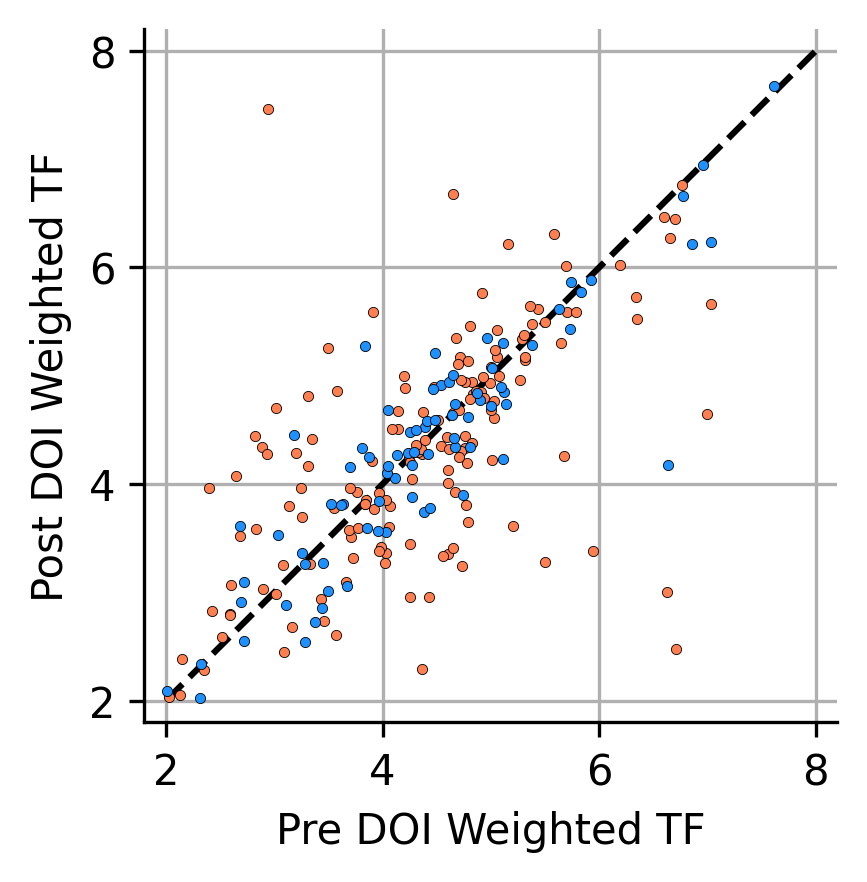

In [320]:
fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)


plt.scatter(WeightedTF_DOI[:,0],WeightedTF_DOI[:,1], color = 'coral', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.scatter(WeightedTF_Saline[:,0],WeightedTF_Saline[:,1], color = 'dodgerblue', s=6,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.plot([2,8],[2,8],color = 'black',linestyle = '--')
plt.xlabel('Pre DOI Weighted TF')
plt.ylabel('Post DOI Weighted TF')
plt.grid()
plt.xticks(ticks=[2,4,6,8],labels=[2,4,6,8])
plt.yticks(ticks=[2,4,6,8],labels=[2,4,6,8])
axs.set_aspect('equal', 'box')
plt.xlim([1.8,8.2])
plt.ylim([1.8,8.2])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath, 'WeightedTF_PrePostInjection.eps'), dpi=300)

In [321]:
PreDOI_Labels_Lim = PreDOI_Labels[DOI_Grating_ResponsivetoBoth.astype(bool)]
PreDOI_Unresp = PreDOI_Labels_Lim == 0
PreDOI_Biphasic = PreDOI_Labels_Lim == 1
PreDOI_Late = PreDOI_Labels_Lim == 2
PreDOI_Early = PreDOI_Labels_Lim == 3
PreDOI_Negative = PreDOI_Labels_Lim == 4

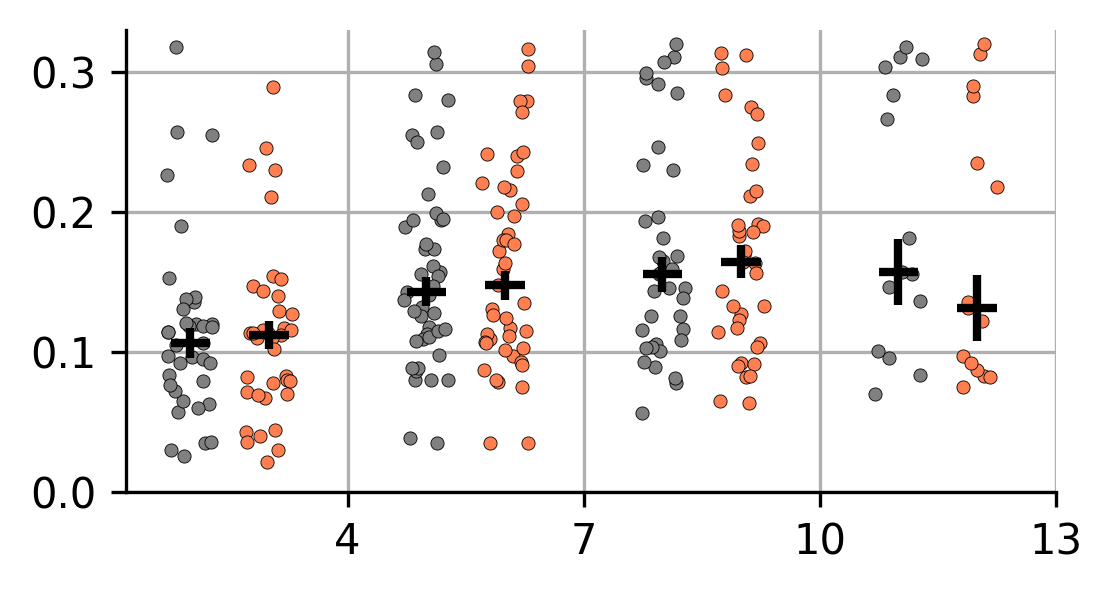

In [324]:
plasma_map = plt.cm.plasma(np.linspace(0,1,15))
clr = [plasma_map[12, :], plasma_map[5,:], plasma_map[8, :], plasma_map[10, :], plasma_map[2, :]]

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(WeightedSF_DOI[PreDOI_Early,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,0])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(WeightedSF_DOI[PreDOI_Early,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,1])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(WeightedSF_DOI[PreDOI_Late,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,0])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(WeightedSF_DOI[PreDOI_Late,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,1])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,0])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,1])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(WeightedSF_DOI[PreDOI_Negative,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,0])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(WeightedSF_DOI[PreDOI_Negative,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,1])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

#plt.plot([np.ones(np.sum(PreDOI_Negative))*11,np.ones(np.sum(PreDOI_Negative))*12],[WeightedSF_DOI[PreDOI_Negative,0],WeightedSF_DOI[PreDOI_Negative,1]],color ='black',alpha= .25)

plt.ylim([.0,.33])
#plt.yticks(ticks=[0,.08,.16,.24,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
#fig.savefig(os.path.join(figpath,'SF_Pref_by_Cluster_PrePostDOI.eps'),dpi=300)

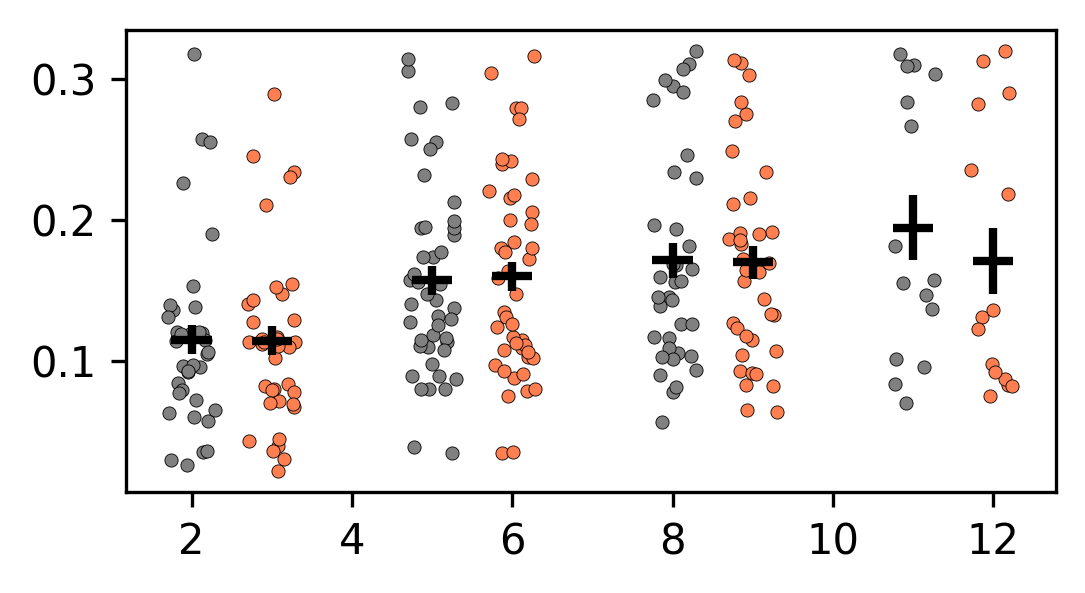

In [323]:

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(WeightedSF_DOI[PreDOI_Early,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,0])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(WeightedSF_DOI[PreDOI_Early,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Early,1])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),WeightedSF_DOI[PreDOI_Early,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(WeightedSF_DOI[PreDOI_Late,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,0])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(WeightedSF_DOI[PreDOI_Late,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Late,1])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),WeightedSF_DOI[PreDOI_Late,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,0])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(WeightedSF_DOI[PreDOI_Biphasic,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Biphasic,1])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),WeightedSF_DOI[PreDOI_Biphasic,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(WeightedSF_DOI[PreDOI_Negative,0]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,0])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(WeightedSF_DOI[PreDOI_Negative,1]),yerr = np.nanstd(WeightedSF_DOI[PreDOI_Negative,1])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),WeightedSF_DOI[PreDOI_Negative,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)


In [ ]:
SF_Oct_Change_DOI = log2(WeightedSF_DOI[:,1])-log2(WeightedSF_DOI[:,0])
SF_Oct_Change_Saline = log2(WeightedSF_Saline[:,1])-log2(WeightedSF_Saline[:,0])

In [ ]:

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)

plt.errorbar(2,np.nanmean(SF_Oct_Change_DOI[PreDOI_Early]),yerr = np.nanstd(SF_Oct_Change_DOI[PreDOI_Early])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(4,np.nanmean(SF_Oct_Change_DOI[PreDOI_Late]),yerr = np.nanstd(SF_Oct_Change_DOI[PreDOI_Late])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(SF_Oct_Change_DOI[PreDOI_Biphasic]),yerr = np.nanstd(SF_Oct_Change_DOI[PreDOI_Biphasic])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(8,np.nanmean(SF_Oct_Change_DOI[PreDOI_Negative]),yerr = np.nanstd(SF_Oct_Change_DOI[PreDOI_Negative])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)

plt.errorbar(3,np.nanmean(SF_Oct_Change_Saline[PreSaline_Early]),yerr = np.nanstd(SF_Oct_Change_Saline[PreSaline_Early])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(5,np.nanmean(SF_Oct_Change_Saline[PreSaline_Late]),yerr = np.nanstd(SF_Oct_Change_Saline[PreSaline_Late])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(7,np.nanmean(SF_Oct_Change_Saline[PreSaline_Biphasic]),yerr = np.nanstd(SF_Oct_Change_Saline[PreSaline_Biphasic])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(SF_Oct_Change_Saline[PreSaline_Negative]),yerr = np.nanstd(SF_Oct_Change_Saline[PreSaline_Negative])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)



In [ ]:
from statsmodels.stats.power import TTestIndPower

n1 = np.sum(PreDOI_Negative)
n2 = np.sum(PreDOI_Negative)

s1 = np.nanvar(WeightedSF_DOI[PreDOI_Negative,0])**2
s2 = np.nanvar(WeightedSF_DOI[PreDOI_Negative,1])**2

s = np.sqrt(((n1-1) * s1 + (n2-1) *s2)/(n1+n2-2))

u1 = np.nanmean(WeightedSF_DOI[PreDOI_Negative,0])
u2 = np.nanmean(WeightedSF_DOI[PreDOI_Negative,1])

d = (u1-u2)/s
print(f'Effect size: {d}')
alpha = .05
power =.8

obj = TTestIndPower()
n = obj.solve_power(effect_size=d, alpha=alpha, power=power, ratio=1, alternative='two-sided')

print('Sample size/Number needed in each group: {:.3f}'.format(n))

In [ ]:
from statsmodels.stats.power import TTestPower

power = TTestPower()
n_test = power.solve_power(nobs=21, effect_size = d,
                           power = None, alpha = 0.05)
print('Power: {:.3f}'.format(n_test))

In [325]:
from scipy import stats
WeightedSF_DOI = np.nan_to_num(WeightedSF_DOI)

t_stat, p_value = stats.wilcoxon(WeightedSF_DOI[PreDOI_Early,0],WeightedSF_DOI[PreDOI_Early,1])
print(t_stat, 't - early')
print(p_value, 'p - early')
t_stat, p_value = stats.wilcoxon(WeightedSF_DOI[PreDOI_Late,0],WeightedSF_DOI[PreDOI_Late,1])
print(t_stat, 't - late')
print(p_value, 'p - late')
t_stat, p_value = stats.wilcoxon(WeightedSF_DOI[PreDOI_Biphasic,0],WeightedSF_DOI[PreDOI_Biphasic,1])
print(t_stat, 't - biphasic')
print(p_value, 'p - biphasic')
t_stat, p_value = stats.wilcoxon(WeightedSF_DOI[PreDOI_Negative,0],WeightedSF_DOI[PreDOI_Negative,1])
print(t_stat, 't - negative')
print(p_value, 'p - negative')

326.0 t - early
0.7092871580534847 p - early
514.0 t - late
0.9732548414619373 p - late
312.0 t - biphasic
0.5605308069789317 p - biphasic
20.0 t - negative
0.02154541015625 p - negative


In [ ]:
PreSaline_Labels_Lim = PreSaline_Labels[Saline_Grating_ResponsivetoBoth.astype(bool)]
PreSaline_Unresp = PreSaline_Labels_Lim == 0
PreSaline_Biphasic = PreSaline_Labels_Lim == 1
PreSaline_Late = PreSaline_Labels_Lim == 2
PreSaline_Early = PreSaline_Labels_Lim == 3
PreSaline_Negative = PreSaline_Labels_Lim == 4

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(WeightedSF_Saline[PreSaline_Early,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Early,0])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(WeightedSF_Saline[PreSaline_Early,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Early,1])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreSaline_Early),.3),WeightedSF_Saline[PreSaline_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),WeightedSF_Saline[PreSaline_Early,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(WeightedSF_Saline[PreSaline_Late,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Late,0])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(WeightedSF_Saline[PreSaline_Late,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Late,1])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreSaline_Late),.3),WeightedSF_Saline[PreSaline_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),WeightedSF_Saline[PreSaline_Late,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(WeightedSF_Saline[PreSaline_Biphasic,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Biphasic,0])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(WeightedSF_Saline[PreSaline_Biphasic,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Biphasic,1])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreSaline_Biphasic),.3),WeightedSF_Saline[PreSaline_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),WeightedSF_Saline[PreSaline_Biphasic,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(WeightedSF_Saline[PreSaline_Negative,0]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Negative,0])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(WeightedSF_Saline[PreSaline_Negative,1]),yerr = np.nanstd(WeightedSF_Saline[PreSaline_Negative,1])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreSaline_Negative),.3),WeightedSF_Saline[PreSaline_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),WeightedSF_Saline[PreSaline_Negative,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([.01,.33])
#plt.yticks(ticks=[0,.08,.16,.24,.32])
plt.yticks(ticks=[0,.1,.2,.3])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'SF_Pref_by_Cluster_PrePostSaline.eps'),dpi=300)

In [ ]:
t_stat, p_value = stats.wilcoxon(WeightedSF_Saline[PreSaline_Early,0],WeightedSF_Saline[PreSaline_Early,1])
print(t_stat, 't - early')
print(p_value, 'p - early')
t_stat, p_value = stats.wilcoxon(WeightedSF_Saline[PreSaline_Late,0],WeightedSF_Saline[PreSaline_Late,1])
print(t_stat, 't - late')
print(p_value, 'p - late')
t_stat, p_value = stats.wilcoxon(WeightedSF_Saline[PreSaline_Biphasic,0],WeightedSF_Saline[PreSaline_Biphasic,1])
print(t_stat, 't - biphasic')
print(p_value, 'p - biphasic')
t_stat, p_value = stats.wilcoxon(WeightedSF_Saline[PreSaline_Negative,0],WeightedSF_Saline[PreSaline_Negative,1])
print(t_stat, 't - negative')
print(p_value, 'p - negative')

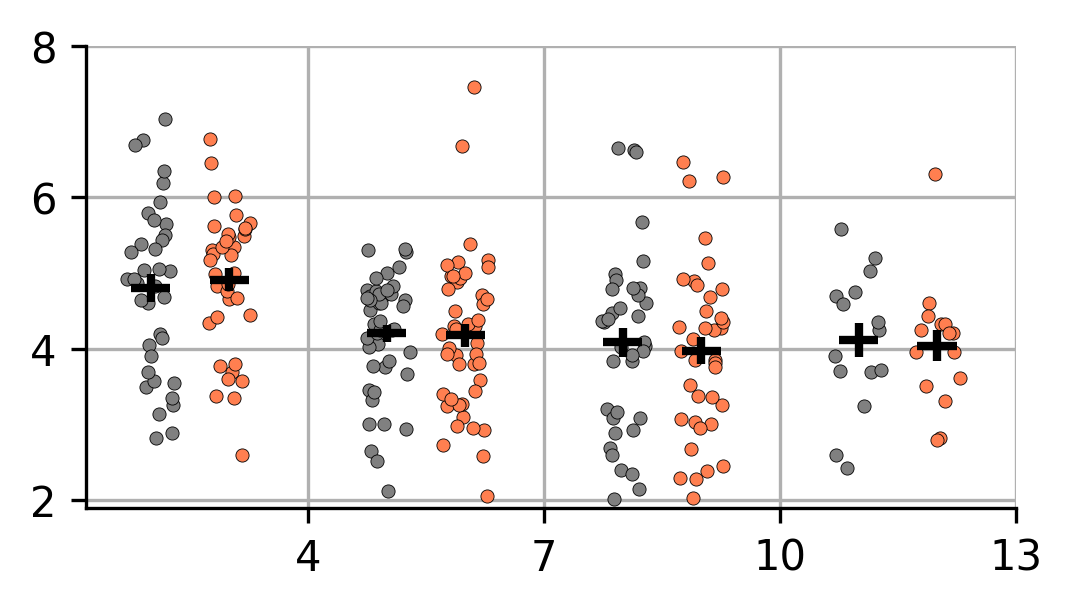

In [427]:
fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmean(WeightedTF_DOI[PreDOI_Early,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Early,0])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmean(WeightedTF_DOI[PreDOI_Early,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Early,1])/sqrt(sum(PreDOI_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreDOI_Early),.3),WeightedTF_DOI[PreDOI_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreDOI_Early),.3),WeightedTF_DOI[PreDOI_Early,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmean(WeightedTF_DOI[PreDOI_Late,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Late,0])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmean(WeightedTF_DOI[PreDOI_Late,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Late,1])/sqrt(sum(PreDOI_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreDOI_Late),.3),WeightedTF_DOI[PreDOI_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreDOI_Late),.3),WeightedTF_DOI[PreDOI_Late,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmean(WeightedTF_DOI[PreDOI_Biphasic,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Biphasic,0])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmean(WeightedTF_DOI[PreDOI_Biphasic,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Biphasic,1])/sqrt(sum(PreDOI_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreDOI_Biphasic),.3),WeightedTF_DOI[PreDOI_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreDOI_Biphasic),.3),WeightedTF_DOI[PreDOI_Biphasic,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmean(WeightedTF_DOI[PreDOI_Negative,0]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Negative,0])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmean(WeightedTF_DOI[PreDOI_Negative,1]),yerr = np.nanstd(WeightedTF_DOI[PreDOI_Negative,1])/sqrt(sum(PreDOI_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreDOI_Negative),.3),WeightedTF_DOI[PreDOI_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreDOI_Negative),.3),WeightedTF_DOI[PreDOI_Negative,1],color = 'coral', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([1.9,8])
plt.yticks(ticks=[2,4,6,8])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'TF_Pref_by_Cluster_PrePostDOI.eps'),dpi=300)

In [ ]:
WeightedTF_DOI = np.nan_to_num(WeightedTF_DOI)

t_stat, p_value = stats.wilcoxon(WeightedTF_DOI[PreDOI_Early,0],WeightedTF_DOI[PreDOI_Early,1])
print(t_stat, 't - early')
print(p_value, 'p - early')
t_stat, p_value = stats.wilcoxon(WeightedTF_DOI[PreDOI_Late,0],WeightedTF_DOI[PreDOI_Late,1])
print(t_stat, 't - late')
print(p_value, 'p - late')
t_stat, p_value = stats.wilcoxon(WeightedTF_DOI[PreDOI_Biphasic,0],WeightedTF_DOI[PreDOI_Biphasic,1])
print(t_stat, 't - biphasic')
print(p_value, 'p - biphasic')
t_stat, p_value = stats.wilcoxon(WeightedTF_DOI[PreDOI_Negative,0],WeightedTF_DOI[PreDOI_Negative,1])
print(t_stat, 't - negative')
print(p_value, 'p - negative')

In [ ]:

fig, axs=plt.subplots(1,1,figsize=(4,2), dpi=300)
plt.errorbar(2,np.nanmedian(WeightedTF_Saline[PreSaline_Early,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Early,0])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(3,np.nanmedian(WeightedTF_Saline[PreSaline_Early,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Early,1])/sqrt(sum(PreSaline_Early)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(1,sum(PreSaline_Early),.3),WeightedTF_Saline[PreSaline_Early,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(2,sum(PreSaline_Early),.3),WeightedTF_Saline[PreSaline_Early,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(5,np.nanmedian(WeightedTF_Saline[PreSaline_Late,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Late,0])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(6,np.nanmedian(WeightedTF_Saline[PreSaline_Late,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Late,1])/sqrt(sum(PreSaline_Late)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(4,sum(PreSaline_Late),.3),WeightedTF_Saline[PreSaline_Late,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(5,sum(PreSaline_Late),.3),WeightedTF_Saline[PreSaline_Late,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(8,np.nanmedian(WeightedTF_Saline[PreSaline_Biphasic,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Biphasic,0])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(9,np.nanmedian(WeightedTF_Saline[PreSaline_Biphasic,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Biphasic,1])/sqrt(sum(PreSaline_Biphasic)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(7,sum(PreSaline_Biphasic),.3),WeightedTF_Saline[PreSaline_Biphasic,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(8,sum(PreSaline_Biphasic),.3),WeightedTF_Saline[PreSaline_Biphasic,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.errorbar(11,np.nanmedian(WeightedTF_Saline[PreSaline_Negative,0]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Negative,0])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.errorbar(12,np.nanmedian(WeightedTF_Saline[PreSaline_Negative,1]),yerr = np.nanstd(WeightedTF_Saline[PreSaline_Negative,1])/sqrt(sum(PreSaline_Negative)),xerr = .25,color = 'black',zorder=6,linewidth=2)
plt.scatter(jitter(10,sum(PreSaline_Negative),.3),WeightedTF_Saline[PreSaline_Negative,0],color = 'grey', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)
plt.scatter(jitter(11,sum(PreSaline_Negative),.3),WeightedTF_Saline[PreSaline_Negative,1],color = 'dodgerblue', s=10,zorder = 3,edgecolor = 'black',linewidth=.2)

plt.ylim([1.9,8])
plt.yticks(ticks=[2,4,6,8])
plt.xticks(ticks= [4,7,10,13])
#plt.xlim(1,25)
plt.grid()
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
fig.savefig(os.path.join(figpath,'TF_Pref_by_Cluster_PrePostSaline.eps'),dpi=300)

In [ ]:
WeightedTF_Saline = np.nan_to_num(WeightedTF_Saline)

t_stat, p_value = stats.wilcoxon(WeightedTF_Saline[PreSaline_Early,0],WeightedTF_Saline[PreSaline_Early,1])
print(t_stat, 't - early')
print(p_value, 'p - early')
t_stat, p_value = stats.wilcoxon(WeightedTF_Saline[PreSaline_Late,0],WeightedTF_Saline[PreSaline_Late,1])
print(t_stat, 't - late')
print(p_value, 'p - late')
t_stat, p_value = stats.wilcoxon(WeightedTF_Saline[PreSaline_Biphasic,0],WeightedTF_Saline[PreSaline_Biphasic,1])
print(t_stat, 't - biphasic')
print(p_value, 'p - biphasic')
t_stat, p_value = stats.wilcoxon(WeightedTF_Saline[PreSaline_Negative,0],WeightedTF_Saline[PreSaline_Negative,1])
print(t_stat, 't - negative')
print(p_value, 'p - negative')